In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import numpy as np
import tifffile
from skimage import measure
import sys
sys.path.append('../../src')
import traceUtilities as tu
import visualisationTools as vt
from scipy.signal import find_peaks, peak_widths
import seaborn as sns

**Notes on statistical unit,grouping and plotting**

After an initial run through the data, the best grouping is from 5-10, 11-12 (activity starts to go down severely) and poshearing. Frequency of calcium events is not significantly different from 5 to 10 days.


For frequency/event-rate analyses, I use mouse-level averages because the quantity is best interpreted as a recording/mouse-level property. Individual cells or events from the same recording are highly correlated, so treating them as independent would inflate the sample size. Therefore, ANOVA on mouse-level summaries is appropriate here.

For event properties such as event duration/width and number of participating cells, the individual event values are biologically meaningful because events within the same mouse can vary substantially. To avoid pseudoreplication while still using this event-level variability, I analyze individual events with a mixed-effects model including mouse as a random effect.

For plotting event properties, I show the event-level distribution to visualize the full variability, and also show one summary point per mouse to make the biological replicate structure clear. The p-value should come from the mixed-effects model, not from the plotted mouse summaries, unless the analysis was explicitly performed on mouse averages.

# Data loading
**Ensure that the `allcells` dataframe load points to the latest version of the analysis in the `analysis_results` folder**

In [7]:
alldata = pd.read_excel('../../alpha9.xlsx')

#Recordings to remove # 1:
recordings_to_remove = pd.read_csv('../../analysis_results/alpha 9_files discard.csv')['difficult to analyse/peak'].tolist()

#Recordings to remove #2: recordings performed with setup 2 (different microscope) that we want to discard for correlation analysis




alldata = alldata[alldata['discard']!=1]
alldata['Folder'] = alldata['Folder'].str.replace('\\','/')

#Remove bad recordings identified in trace analysis
print(f"Current recordings: {len(alldata)}")
alldata = alldata[~alldata['Folder'].isin(recordings_to_remove)]
print(f"Current recordings: {len(alldata)}")

alldata2 = alldata.copy() # before changing the drive

#drive = '/media/marcotti-lab'

#alldata['Folder'] = alldata['Folder'].str.replace('Z:',drive).str.replace('\\','/')



# Let's analyse the peaks after selection

allcells = pd.read_excel('../../analysis_results/alpha9.xlsxnew20260811.xlsx')
#Transform the peak positions column into a list using ast
import ast

def safe_literal_eval(val):
    #remove np.int64 and parentesis
    val = val.replace('np.int64','').replace('(','').replace(')','')
    try:
        return ast.literal_eval(val)  
    except (ValueError, SyntaxError):
        print(val)


allcells['Peak positions'] = allcells['Peak positions'].apply(safe_literal_eval)

#Remove bad recordings
allcells = allcells[~allcells['Folder'].isin(recordings_to_remove)]

#Remove bad cells
cells_to_remove = pd.read_csv('../../analysis_results/alpha 9_rois discard.csv')['cell name'].tolist()
total_cells = len(allcells)
allcells = allcells[~allcells['Cell ID'].isin(cells_to_remove)]
print(f"✓ Loaded allcells: {len(allcells)} cells, discarded {total_cells-len(allcells)} cells that were manually discarded after trace analysis")

#Load traces 
alltraces = pd.read_parquet('../../analysis_results/alpha9_events_alltraces.parquet')


#Determine recording duration for all the cells
allcells['Recording duration'] = None
for j,subcells in allcells.groupby('Folder'):
    recording_duration = (alltraces[subcells['Cell ID']].dropna()).shape[0]/subcells['fps'].values[0]
    allcells.loc[allcells['Folder']==j,'Recording duration'] = recording_duration

#Remove cells not in alldata (e.g. cells from recordings that were discarded after trace analysis)
total_cells = len(allcells)
allcells = allcells[allcells['Folder'].isin(alldata2['Folder'])]
print(f"✓ Loaded allcells: {len(allcells)} cells, discarded {total_cells-len(allcells)} cells from recordings that were discarded after trace analysis")

Current recordings: 465
Current recordings: 412
✓ Loaded allcells: 6788 cells, discarded 94 cells that were manually discarded after trace analysis
✓ Loaded allcells: 6788 cells, discarded 0 cells from recordings that were discarded after trace analysis


In [8]:
allcells

,Unnamed: 0,Date,Folder,RoiN,Cell type,Mouse ID,Strain,Age,fps,Peak prominence,...,Centroid y,Centroid x um,Centroid y um,Independent recordings number,Number in sequence,Cell ID,Discard,Independent recordings ID,Matched RoiN,Recording duration
0,0,2026.02.19,Z:/Users/Rinta/Data/2026/In vivo/2026_02_19 P5...,ROI_1,1,81,control,5,24.480,4.01,...,201.726788,24.317218,46.408981,183,1,2026.02.19_control_81_1_003_ROI_1,NaN,control_183.0,1,482.352941
1,1,2026.02.19,Z:/Users/Rinta/Data/2026/In vivo/2026_02_19 P5...,ROI_2,1,81,control,5,24.480,4.01,...,237.872727,23.412715,54.724665,183,1,2026.02.19_control_81_1_003_ROI_2,NaN,control_183.0,2,482.352941
2,2,2026.02.19,Z:/Users/Rinta/Data/2026/In vivo/2026_02_19 P5...,ROI_3,1,81,control,5,24.480,4.01,...,279.824610,22.347583,64.376056,183,1,2026.02.19_control_81_1_003_ROI_3,NaN,control_183.0,3,482.352941
3,3,2026.02.19,Z:/Users/Rinta/Data/2026/In vivo/2026_02_19 P5...,ROI_4,1,81,control,5,24.480,4.01,...,318.520333,22.576147,73.278340,183,1,2026.02.19_control_81_1_003_ROI_4,NaN,control_183.0,4,482.352941
4,4,2026.02.19,Z:/Users/Rinta/Data/2026/In vivo/2026_02_19 P5...,ROI_5,1,81,control,5,24.480,4.01,...,349.309476,16.446064,80.361647,183,1,2026.02.19_control_81_1_003_ROI_5,NaN,control_183.0,5,482.352941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7712,7712,2025.08.27,Z:/Users/Francesca/Data/2025/2025_08_27_a9KO-M...,ROI_18,1,18,alpha9KO,14,22.279,4.95,...,658.497436,41.643808,151.492994,63,2,2025.08.27_alpha9KO_18_3_001_ROI_18,NaN,alpha9KO_63.0,18,367.74541
7713,7713,2025.08.27,Z:/Users/Francesca/Data/2025/2025_08_27_a9KO-M...,ROI_19,1,18,alpha9KO,14,22.279,4.95,...,693.178646,44.949564,159.471705,63,2,2025.08.27_alpha9KO_18_3_001_ROI_19,NaN,alpha9KO_63.0,19,367.74541
7714,7714,2025.08.27,Z:/Users/Francesca/Data/2025/2025_08_27_a9KO-M...,ROI_20,1,18,alpha9KO,14,22.279,4.95,...,729.721602,40.857379,167.878726,63,2,2025.08.27_alpha9KO_18_3_001_ROI_20,NaN,alpha9KO_63.0,20,367.74541
7715,7715,2025.08.27,Z:/Users/Francesca/Data/2025/2025_08_27_a9KO-M...,ROI_21,1,18,alpha9KO,14,22.279,4.95,...,768.677284,44.190920,176.840815,63,2,2025.08.27_alpha9KO_18_3_001_ROI_21,NaN,alpha9KO_63.0,21,367.74541


In [88]:
allcells.groupby('Folder').count()['Date'].sort_values(ascending=False)

Folder
Z:/Users/Francesca/Data/2025/2025_08_22_a9KO-Myo15-GCaMP6f_P9_in vivo/3             30
Z:/Users/Francesca/Data/2025/2025_08_26_a9KO-Myo15-GCaMP6f_P13_in vivo/6            29
Z:/Users/Francesca/Data/2025/2025_09_09_a9KO-Myo15-GCaMP6f_P12_in vivo/5_001        29
Z:/Users/Francesca/Data/2025/2025_08_11_a9KO-Myo15-GCaMP6f_P11_in vivo/4            29
Z:/Users/Francesca/Data/2025/2025_09_09_a9KO-Myo15-GCaMP6f_P12_in vivo/4_002        28
                                                                                    ..
Z:/Users/Rinta/Data/2025/In vivo/20251118_P9_In vivo_Myo15CreGCAMP_setup 1/5_001     3
Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-Myo15-GCaMP6f_P7_in vivo/7_001          3
Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-Myo15-GCaMP6f_P7_in vivo/7              3
Z:/Users/Rinta/Data/2026/In vivo/2026_01-22 P9 Invivo_MyocreGcamp/1                  3
Z:/Users/Francesca/Data/2025/2025_09_05_a9KO-Myo15-GCaMP6f_P11_in vivo/1_002         1
Name: Date, Length: 412, dtype: int6

# Calculate Peak widths for each peak
This is not to be confused with the "event width" later. The event width is essentially the average (median) of the width of individualy calcium spikes appearing simultaneously in hair cells. 

We use this cell to calculate the widths of calcium spikes, so that they can be averaged later. Although statistic are calculated for this quantity, I would advise to just talk about "events" to not confound the reader.

Also, the statistics is anova+mann-u posttest, which is not appropriate for this measurement (probably cells and mouseID should be used as random factors).

In [9]:
#Calculate peak widths for all cells
peaks = []

for j,cell in allcells.iterrows():
        this_df = pd.DataFrame({'Cell ID':[cell['Cell ID']]*len(cell['Peak positions']),'Peak position':cell['Peak positions'], 'Mouse ID':[cell['Mouse ID']]*len(cell['Peak positions']), 
                                    'Folder':[cell['Folder']]*len(cell['Peak positions']), 'Strain':[cell['Strain']]*len(cell['Peak positions']), 'Age':[cell['Age']]*len(cell['Peak positions'])})
        trace = alltraces[cell['Cell ID']].dropna().values
        trace_z = tu.detrend_z_score(alltraces[cell['Cell ID']].dropna(),rollingN = 2000,savgol_order=21) # recover the original trace used to detect peaks.

        peak_widths_results = peak_widths(trace_z, cell['Peak positions'], rel_height=0.5)
        this_df['Peak width'] = peak_widths_results[0]/cell['fps']
        peaks.append(this_df)

single_peak_df = pd.concat(peaks,ignore_index=True)


In [10]:
single_peak_df['Age group'] = 'P5-10'
single_peak_df.loc[single_peak_df['Age']>10, 'Age group'] = 'P11-12'
single_peak_df.loc[single_peak_df['Age']>12, 'Age group'] = 'P13-15'

In [11]:
single_peak_df_by_mouse = single_peak_df[single_peak_df['Peak width']<=60].groupby(['Mouse ID','Strain','Age']).agg({'Peak width':'mean','Age group':'first'}).reset_index()
#single_peak_df_by_cell = single_peak_df[single_peak_df['Peak width']<=60].groupby(['Cell ID','Strain','Age']).agg({'Peak width':'mean','Age group':'first'}).reset_index()

<Figure size 640x480 with 0 Axes>

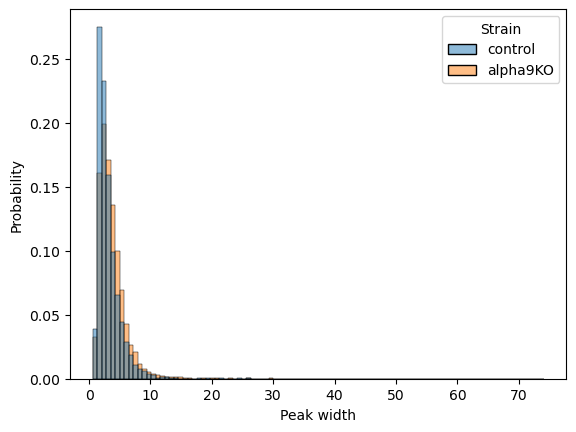

<Figure size 640x480 with 0 Axes>

In [12]:
sns.histplot(data=single_peak_df[(single_peak_df['Age']>=5) & (single_peak_df['Age']<=10)],x='Peak width',hue='Strain',stat='probability',common_norm=False,bins=100)
plt.figure()

#set yscale to log
#plt.yscale('log')
#plt.xlim(0,30)

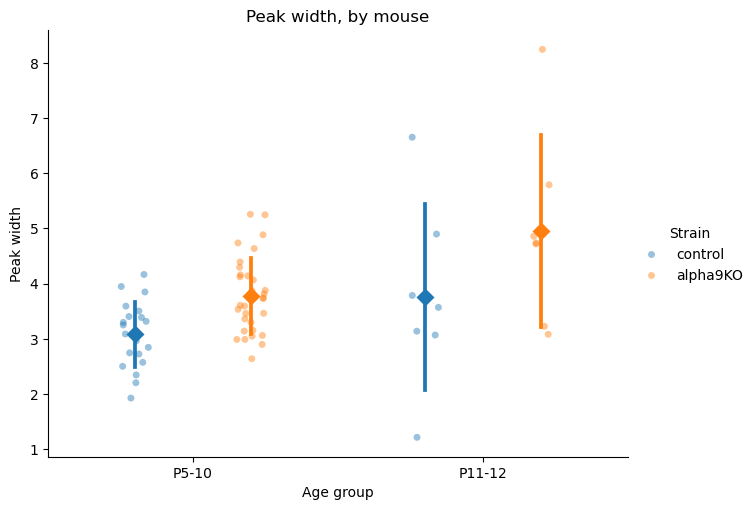

In [13]:
#sns.catplot(data=single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=5 )& (single_peak_df_by_mouse['Age']<=15)],x= 'Age',hue='Strain',y='Peak width',kind= 'strip')
g = sns.catplot(
    data=single_peak_df_by_mouse[single_peak_df_by_mouse['Age']<=12],
    x="Age group",
    y="Peak width",
    hue="Strain",
    kind="strip",          # individual datapoints
    dodge=True,
    jitter=True,
    alpha=0.45,
    height=5,
    aspect=1.3,
    hue_order = ['control','alpha9KO']
)

sns.pointplot(
    data=single_peak_df_by_mouse[single_peak_df_by_mouse['Age']<=12],
    x="Age group",
    y="Peak width",
    hue="Strain",
    dodge=0.4,
    errorbar="sd",         # or "sd", "ci", None
    markers="D",
    linestyles="none",
    hue_order = ['control','alpha9KO'],
    ax=g.ax,
    legend=False           # avoids duplicate legend
)

plt.title('Peak width, by mouse')
plt.show()

In [14]:
from scipy.stats import mannwhitneyu
x = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=5) & (single_peak_df_by_mouse['Age']<=10) & (single_peak_df_by_mouse['Strain']=='control')]['Peak width']
y = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=5) & (single_peak_df_by_mouse['Age']<=10) & (single_peak_df_by_mouse['Strain']=='alpha9KO')]['Peak width']
mannwhitneyu(x,y,alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(149.0), pvalue=np.float64(0.0010297341199026777))

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=5) & (single_peak_df_by_mouse['Age']<=12)]
# keep only needed columns and drop missing values
d = df[["Peak width", "Strain", "Age group"]].dropna()
d.rename(columns={'Age group':'Agegroup', 'Peak width':'Peakwidth'}, inplace=True)
# If Distance_bin_center is a binned/category variable:
model = ols(
    "Peakwidth ~ C(Strain) * C(Agegroup)",

    data=d
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


from scipy.stats import mannwhitneyu

from statsmodels.stats.multitest import multipletests
p510_ctrl = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=5) & (single_peak_df_by_mouse['Age']<=10) & (single_peak_df_by_mouse['Strain']=='control')]['Peak width']
p510_ko = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=5) & (single_peak_df_by_mouse['Age']<=10) & (single_peak_df_by_mouse['Strain']=='alpha9KO')]['Peak width']
p1112_ctrl = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=11) & (single_peak_df_by_mouse['Age']<=12) & (single_peak_df_by_mouse['Strain']=='control')]['Peak width']
p1112_ko = single_peak_df_by_mouse[(single_peak_df_by_mouse['Age']>=11) & (single_peak_df_by_mouse['Age']<=12) & (single_peak_df_by_mouse['Strain']=='alpha9KO')]['Peak width']

p1 = mannwhitneyu(p510_ctrl, p510_ko).pvalue

p2 = mannwhitneyu(p1112_ctrl, p1112_ko).pvalue

p = multipletests([p1, p2], method="holm")[1]

print('\nPairwise mann-whitney U tests with Holm-Bonferroni correction:')
print(f"p-value for P5-10: {p[0]}")
print(f"p-value for P11-12: {p[1]}")


                          sum_sq    df          F    PR(>F)
C(Strain)              10.409697   1.0  11.481772  0.001226
C(Agegroup)             9.570466   1.0  10.556111  0.001872
C(Strain):C(Agegroup)   0.656801   1.0   0.724443  0.397966
Residual               56.210937  62.0        NaN       NaN

Pairwise mann-whitney U tests with Holm-Bonferroni correction:
p-value for P5-10: 0.0020594682398053553
p-value for P11-12: 0.31759906759906764


## Conclusion
There is a significant difference in duration at P5-10, while no clear difference is visible at P11-12. Report the mice and individual points. consider plotting the histogram as well. 

# Concatenate the traces for repeated recording
We combine the traces so that subsequent recording of the same cell are concatenated, with a padding of nans.

Errors are reported if a cell has inconsistencies, like two cells in the same recording with the same `Matched ROI number`

In [16]:

errors = []
rid_witherrors = []
alltraces_combined = {}
for rid in allcells['Independent recordings ID'].unique():
    subcells = allcells[allcells['Independent recordings ID']==rid]

    matchedroin = subcells['Matched RoiN'].unique()

    nuniquecells = len(matchedroin)
    nsequences = len(subcells['Number in sequence'].unique())


    #determine the length of the different sequences
    lengths = {}
    for j in subcells['Number in sequence'].unique():
        randomcellid = subcells[subcells['Number in sequence']==j]['Cell ID'].values[0]

        # Get the trace for this cell
        trace = alltraces[randomcellid].dropna()
        lengths[j] = len(trace) 
    print(f'Independent recording {rid} has {nuniquecells} unique cells and {nsequences} sequences with lengths {lengths}')

    traces_out = np.zeros((nuniquecells+1,sum(lengths.values())+100*(len(lengths)))).T*np.nan

    headers = [rid+'-'+str(j) for j in matchedroin] + ['Time (s)']
    traces_out = pd.DataFrame(columns=headers, data=traces_out)

    for roiposition,j in enumerate(matchedroin): 

        for index,seq in enumerate(subcells['Number in sequence'].unique()):
            #Get the cell ID for this sequence
            cellid = subcells[(subcells['Matched RoiN']==j) & (subcells['Number in sequence']==seq)]['Cell ID'].values
            if len(cellid)==0:
                continue
            elif len(cellid)>1:
                errors.append(f'More than one cell ID found for matched roin {j} and recording {rid}')
                rid_witherrors.append(rid)
                continue
            cellid = cellid[0]

            trace = alltraces[cellid].dropna()
            
            startindex = 0 
            for k in subcells['Number in sequence'].unique():
                if k==seq:
                    break
                startindex += lengths[k] + 100

            traces_out.iloc[startindex:startindex+len(trace),roiposition] = trace.values
    time = np.arange(0,traces_out.shape[0])/subcells['fps'].values[0]
    traces_out.loc[:,'Time (s)'] = time
    alltraces_combined[rid] = traces_out


Independent recording control_183.0 has 17 unique cells and 1 sequences with lengths {np.int64(1): 11808}
Independent recording control_184.0 has 22 unique cells and 2 sequences with lengths {np.int64(1): 7427, np.int64(2): 7244}
Independent recording control_185.0 has 24 unique cells and 1 sequences with lengths {np.int64(1): 15081}
Independent recording alpha9KO_192.0 has 14 unique cells and 2 sequences with lengths {np.int64(1): 7054, np.int64(2): 8111}
Independent recording alpha9KO_193.0 has 23 unique cells and 1 sequences with lengths {np.int64(1): 19270}
Independent recording alpha9KO_196.0 has 13 unique cells and 1 sequences with lengths {np.int64(1): 9522}
Independent recording alpha9KO_197.0 has 17 unique cells and 1 sequences with lengths {np.int64(1): 10068}
Independent recording control_198.0 has 21 unique cells and 3 sequences with lengths {np.int64(1): 4048, np.int64(2): 6824, np.int64(3): 5267}
Independent recording control_199.0 has 22 unique cells and 2 sequences with

In [17]:
errors

[]

In [18]:
rid_witherrors

[]

# Combine the `allcells` Dataframe in the `allcells_combined`.
Where repeatedly imaged cells are reported only once.

We also average by mouse and recording (i.e., all the properties from the cells from the same mouse/recording are averaged).

In [19]:
allcells['Matched Roi ID'] = allcells['Independent recordings ID'] + '-' + allcells['Matched RoiN'].astype(str)

allcells['Number of peaks'] = allcells['Peak positions'].apply(lambda x:len(x))

allcells['Frequency of peaks (1/min)'] = allcells['Number of peaks']/allcells['Recording duration'] * 60

allcells_combined = allcells.groupby('Matched Roi ID').agg({
    'Number of peaks': 'sum',
    'Recording duration': 'sum',
    'Mouse ID': 'first',
    'Strain': 'first',
    'Age': 'first',
    'Folder': 'first',
    'Independent recordings ID': 'first',
    'Centroid x um': 'mean',    #TODO : FIND A BETTER WAY TO DO THIS
    'Centroid y um': 'mean'
    }).reset_index()



## Optional step: remove mice with less than X cells
As some mice have 100s of cells and a few have less than 10, it would make sense to remove these mice. 
However, removing these mice does not change anything in terms of statistics, so we may as well leave them to avoid overcomplicating the methods.

`MIN_CELL_COUNT_THRESHOLD` is set to 0, change it to higher amount to exclude mice with fewer cells (10 is a good threshold).

In [20]:
MIN_CELL_COUNT_THRESHOLD = 00

boolind = allcells_combined.groupby(['Mouse ID']).count()['Matched Roi ID']>=MIN_CELL_COUNT_THRESHOLD

current_mouse_count = len(allcells_combined['Mouse ID'].unique())
current_cell_count = len(allcells_combined)

allcells_combined = allcells_combined[allcells_combined['Mouse ID'].isin(boolind[boolind].index)]

print(f"Removed {current_mouse_count-len(allcells_combined['Mouse ID'].unique())} mice and {current_cell_count-len(allcells_combined)} cells with less than {MIN_CELL_COUNT_THRESHOLD} cells. Current mouse count: {len(allcells_combined['Mouse ID'].unique())}, current cell count: {len(allcells_combined)}")

Removed 0 mice and 0 cells with less than 0 cells. Current mouse count: 76, current cell count: 3506


## Average by mouse and recording
At this point we average by mouse and `Independent recording ID`

In [21]:
allcells_combined['Frequency of peaks (1/min)'] = allcells_combined['Number of peaks']/allcells_combined['Recording duration'] * 60

#Remove cells less than 5 minutes
TIME_THRESHOLD = 5*60
print(f"We are discarding {sum(allcells_combined['Recording duration']<TIME_THRESHOLD)} cells out of {len(allcells_combined)} because they are shorter than {TIME_THRESHOLD/60} minutes")
allcells_combined = allcells_combined[allcells_combined['Recording duration']>=TIME_THRESHOLD]

#Remove cells with no activity?
#allcells_combined = allcells_combined[allcells_combined['Frequency of peaks (1/min)']>=0]


allcells_combined_by_recording = allcells_combined.groupby('Independent recordings ID').agg({
    'Frequency of peaks (1/min)': 'mean',
    'Mouse ID': 'first',
    'Strain': 'first',
    'Age': 'first',
    'Folder': 'first',
    'Matched Roi ID': 'count'
}).reset_index()
allcells_combined_by_recording.rename(columns={'Matched Roi ID':'Number of cells'}, inplace=True)


allcells_by_mouse = allcells_combined.groupby('Mouse ID').agg({'Frequency of peaks (1/min)':'mean','Age':'first','Strain':'first','Folder':'count'}).reset_index()
allcells_by_mouse.rename(columns={'Folder':'Number of cells'}, inplace=True)

We are discarding 289 cells out of 3506 because they are shorter than 5.0 minutes


# Define age groups. 

For individual plots, sometimes we use just the data from 5 to 10. I did not use global variables for this, so I should check that all the instances are changed in case we want to plot the data in another way.

In [60]:
#Age groups
#allcells_by_mouse['Age group'] = pd.cut(allcells_by_mouse['Age'], bins=[4, 6, 8, 10, 12,14], labels=['5-6', '7-8', '9-10', '11-12', '13-14'])
allcells_by_mouse['Age group'] = pd.cut(allcells_by_mouse['Age'], bins=[4, 10,12,14], labels=['5-10', '11-12', '13-14'])
#Check
allcells_by_mouse.groupby('Age')['Age group'].first()

Age
5      5-10
6      5-10
7      5-10
8      5-10
9      5-10
10     5-10
11    11-12
12    11-12
13    13-14
14    13-14
Name: Age group, dtype: category
Categories (3, object): ['5-10' < '11-12' < '13-14']

# Analysis of frequency of peaks.

This include ALL calcium events, not only coordinated ones. 

## Are we justified in grouping 5-10 together? Are there any difference with age within this group?

In [61]:
import statsmodels.formula.api as smf
anova_df = allcells_by_mouse[
    ['Frequency of peaks (1/min)', 'Age', 'Strain', 'Age group']
].dropna().copy()
anova_df.rename(columns={'Frequency of peaks (1/min)':'Fop'}, inplace=True)

anova_df = anova_df[anova_df['Age']<=15]

# Force dependent variable to numeric
anova_df['Fop'] = pd.to_numeric(anova_df['Fop'], errors='coerce')

# Drop rows where any needed value is missing
anova_df = anova_df.dropna(subset=['Fop', 'Age', 'Strain'])

# Treat predictors as categorical factors
anova_df['Age'] = anova_df['Age'].astype('category')
anova_df['Agegroup'] = pd.cut(anova_df['Age'], bins=[4, 10,12,14], labels=['5-10', '11-12', '13-14'])
anova_df['Strain'] = anova_df['Strain'].astype('category')

df = anova_df.copy()
df["Age_num"] = pd.to_numeric(df["Age"].astype(str).str.extract(r"(\d+)")[0])

early = df[df["Age_num"].between(5, 10)].copy()
early["Age_c"] = early["Age_num"] - early["Age_num"].mean()

model = smf.mixedlm("Fop ~ Age_c", data=early, groups=early.index).fit()
print(model.summary())

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Fop    
No. Observations: 52      Method:             REML   
No. Groups:       52      Scale:              0.0275 
Min. group size:  1       Log-Likelihood:     -2.7863
Max. group size:  1       Converged:          Yes    
Mean group size:  1.0                                
-----------------------------------------------------
           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept   0.766    0.031 24.956 0.000  0.706  0.826
Age_c      -0.010    0.007 -1.389 0.165 -0.024  0.004
Group Var   0.027                                    



/Users/federico/miniforge3/envs/napari/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


No significant effect of age on frequency between P5-P10, we can group them.

## Plots

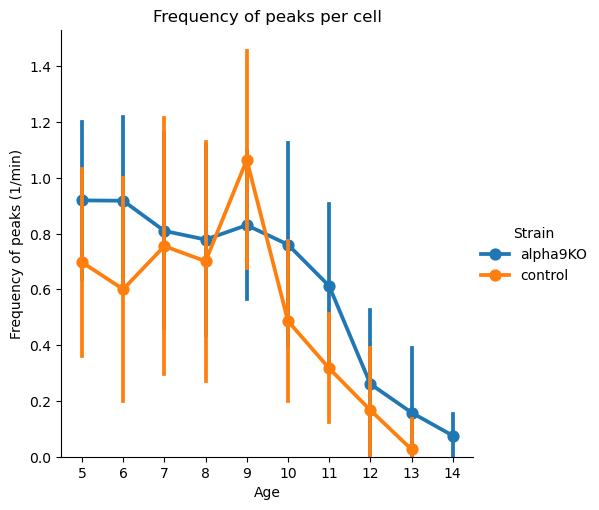

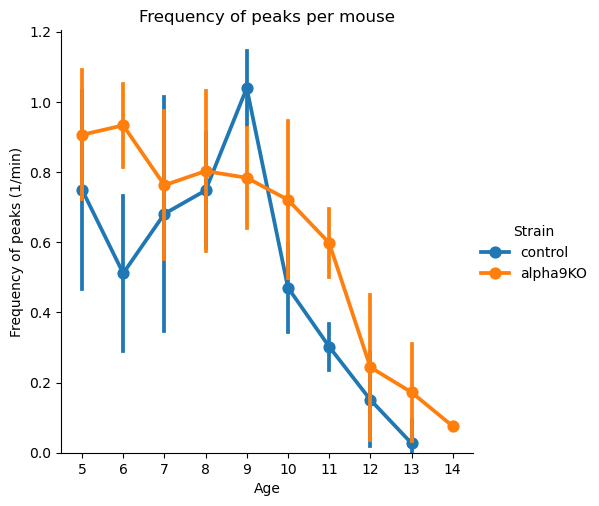

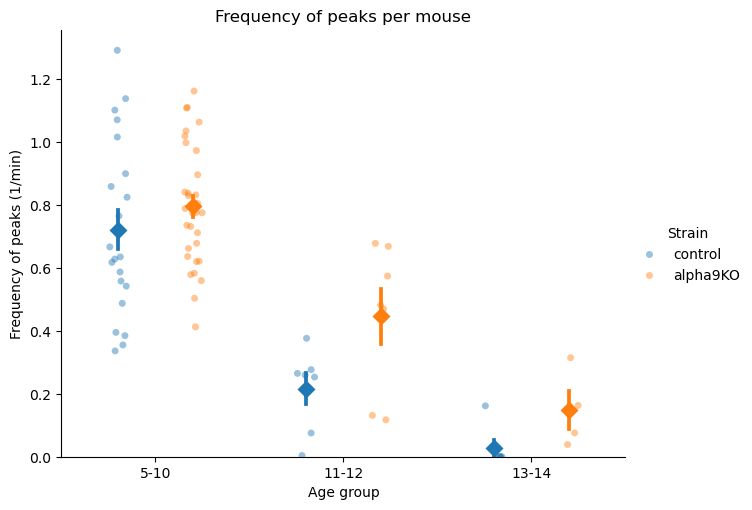

(0.0, 1.3565476906397724)

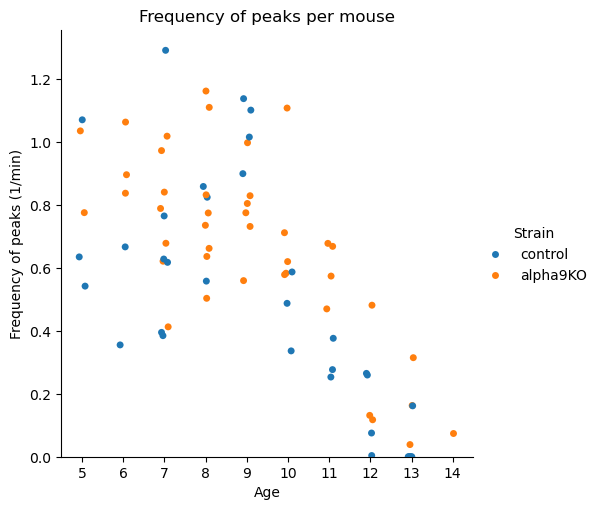

In [26]:
sns.catplot(data=allcells_combined[(allcells_combined['Age']>=5 )& (allcells_combined['Age']<=15)],x= 'Age',hue='Strain',y='Frequency of peaks (1/min)',kind= 'point',errorbar='sd')
plt.title('Frequency of peaks per cell')
plt.ylim(0,)



sns.catplot(data=allcells_by_mouse[(allcells_by_mouse['Age']>=5 )& (allcells_by_mouse['Age']<=15)],x= 'Age',y='Frequency of peaks (1/min)',hue='Strain',kind= 'point',errorbar='sd')
plt.title('Frequency of peaks per mouse')
plt.ylim(0,)

import seaborn as sns
import matplotlib.pyplot as plt

plot_df = allcells_by_mouse[
    (allcells_by_mouse["Age"] >= 5) &
    (allcells_by_mouse["Age"] <= 15)
].copy()

g = sns.catplot(
    data=plot_df,
    x="Age group",
    y="Frequency of peaks (1/min)",
    hue="Strain",
    kind="strip",
    dodge=True,
    jitter=True,
    alpha=0.45,
    height=5,
    aspect=1.3,
    hue_order=['control', 'alpha9KO']
)

sns.pointplot(
    data=plot_df,
    x="Age group",
    y="Frequency of peaks (1/min)",
    hue="Strain",
    dodge=0.4,
    errorbar="se",      # use "sd", "ci", or None if preferred
    markers="D",
    linestyles="none",
    hue_order=['control', 'alpha9KO'],
    ax=g.ax,
    legend=False
)

plt.title("Frequency of peaks per mouse")
plt.ylim(0,)
plt.show()

sns.catplot(data=allcells_by_mouse[(allcells_by_mouse['Age']>=5 )& (allcells_by_mouse['Age']<=15)],x= 'Age',y='Frequency of peaks (1/min)',hue='Strain',kind= 'strip')
plt.title('Frequency of peaks per mouse')
plt.ylim(0,)


## Statistics of frequency of calcium peaks

In [27]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

anova_df = allcells_by_mouse[
    ['Frequency of peaks (1/min)', 'Age', 'Strain', 'Age group']
].dropna().copy()
anova_df.rename(columns={'Frequency of peaks (1/min)':'Fop'}, inplace=True)

anova_df = anova_df[anova_df['Age']<=15]

# Force dependent variable to numeric
anova_df['Fop'] = pd.to_numeric(anova_df['Fop'], errors='coerce')

# Drop rows where any needed value is missing
anova_df = anova_df.dropna(subset=['Fop', 'Age', 'Strain'])

# Treat predictors as categorical factors
anova_df['Age'] = anova_df['Age'].astype('category')
anova_df['Agegroup'] = pd.cut(anova_df['Age'], bins=[4, 10,12,14], labels=['5-10', '11-12', '13-14'])
anova_df['Strain'] = anova_df['Strain'].astype('category')

# Two-way ANOVA with Age, Strain, and Age x Strain interaction
model = ols(
    'Fop ~ C(Agegroup) * C(Strain)',
    data=anova_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
anova_table








,sum_sq,df,F,PR(>F)
C(Agegroup),4.806148,2.0,52.754171,1.066620e-14
C(Strain),0.221009,1.0,4.851755,3.091274e-02
C(Agegroup):C(Strain),0.067449,2.0,0.740341,4.806480e-01
Residual,3.188661,70.0,NaN,NaN


In [28]:
# Postest: multiuple mann-whitney U tests for each age group, with Holm-Bonferroni correction (perform only if the ANOVA shows a significant effect of Strain or Age x Strain interaction)

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

posthoc_results = []

for age, age_df in anova_df.groupby('Agegroup'):
    control = age_df.loc[age_df['Strain'] == 'control', 'Fop'].dropna()
    ko = age_df.loc[age_df['Strain'] == 'alpha9KO', 'Fop'].dropna()

    if len(control) > 0 and len(ko) > 0:
        stat, p = mannwhitneyu(control, ko, alternative='two-sided')

        posthoc_results.append({
            'Age': age,
            'n_control': len(control),
            'n_alpha9KO': len(ko),
            'mean_control': control.mean(),
            'mean_alpha9KO': ko.mean(),
            'statistic': stat,
            'p_uncorrected': p,
        })

posthoc_df = pd.DataFrame(posthoc_results)

posthoc_df['p_corrected'] = multipletests(
    posthoc_df['p_uncorrected'],
    method='holm'
)[1]

posthoc_df['significant'] = posthoc_df['p_corrected'] < 0.05

posthoc_df

/var/folders/n2/bkzw0ff907zgpgprdz_rg_tr0000gn/T/ipykernel_11176/501169590.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age, age_df in anova_df.groupby('Agegroup'):


,Age,n_control,n_alpha9KO,mean_control,mean_alpha9KO,statistic,p_uncorrected,p_corrected,significant
0,5-10,21,31,0.722143,0.795743,256.0,0.198164,0.198164,False
1,11-12,7,7,0.215776,0.445981,10.0,0.072844,0.145688,False
2,13-14,6,4,0.026958,0.147998,2.0,0.030728,0.092184,False


## Conclusions
No significant difference exists between frequency of the strains. I want to compare grouping 5-10 (the linear mixed model show them as not-significant) day old mice together, however every other slicing of the data by age is not significant, so it does not matter.
I would show the average frequency by mouse, without the histograms.


# Analysis of correlation.

As done before, we analyse correlation as a function of distance between two cells.

Assumptions:
- Correlation is calculated only if two cells have at least 5 minute of recording in common. 
- Distance is calculated by averaging the distance of two cells in every recording they appear together. 
- Each couple of cells is counted only once (obviously).
- Averages, std and statistics are done with the Fisher's z-transform (arctanh).

In [69]:
import tqdm
result_rows = []
MIN_PERIOD_MINUTES = 5
for rid in tqdm.tqdm(allcells_combined['Independent recordings ID'].unique()):
    trace = alltraces_combined[rid].copy()

    el = allcells_combined[allcells_combined['Independent recordings ID']==rid]
    trace = trace[el['Matched Roi ID'].values.tolist() + ['Time (s)']]
    
    time = trace['Time (s)'].values
    fps = 1/np.mean(np.diff(time))
    trace.drop(columns='Time (s)', inplace=True)

    trace.iloc[:,:] = tu.rollingMedianCorrection(trace,rollingN=2000) + np.tile(trace.iloc[0,:], (trace.shape[0], 1))
    trace_orig = trace.copy()

        #Estimating activity using z score normalization, which is more robust to baseline drift than dF/F. 
    traces_z = (trace - trace.mean())/trace.std()
    # Find calcium peaks in the traces using find_peaks from scipy
    #traces_dff0 = tu.calculatedFF0(trace_orig.values,f0Frames='percentile',percentile=20)
    
        #Traces have groups of neighboring frames that are constant due to skipped frames. We remove those frames to avoid biasing the correlation.
    trace = trace[trace.diff().abs().sum(axis=1)>0]


    # We add a dataframe with the cross correlation between every pair of traces
    corr = trace.corr(min_periods=int(MIN_PERIOD_MINUTES*60*fps))
    corr = corr.where(~np.tril(np.ones(corr.shape)).astype(bool)).stack().reset_index()
    corr.columns = ['Trace1','Trace2','Correlation']
    corr['Folder'] = el['Folder'].values[0]
    corr['Age'] = el['Age'].values[0]
    corr['Strain'] = el['Strain'].values[0]
#    corr['Genotype'] = el['Genotype'].values[0]
    corr['Mouse ID'] = el['Mouse ID'].values[0]
   # corr['Duration'] = trace.shape[0]/el['fps']


    #For each pair of cells, determine the distance from the mask
    for i,row in corr.iterrows():
        cell1 = row['Trace1']
        cell2 = row['Trace2']
        x1,y1 = el[el['Matched Roi ID']==cell1][['Centroid x um','Centroid y um']].values[0]
        x2,y2 = el[el['Matched Roi ID']==cell2][['Centroid x um','Centroid y um']].values[0]
        #distance = np.sqrt((x1-x2)**2 + (y1-y2)**2)
        #Better way to calculate the distance. We go back to the allcells dataframe, calculate the distance of the pair in every sequence and then average.
        cell1_all = allcells[allcells['Matched Roi ID']==cell1]
        cell2_all = allcells[allcells['Matched Roi ID']==cell2]
        # keep only the common sequences
        common_sequences = set(cell1_all['Number in sequence']).intersection(set(cell2_all['Number in sequence']))
        this_distances = []
        for seq in common_sequences:
            x1_seq,y1_seq = cell1_all[cell1_all['Number in sequence']==seq][['Centroid x um','Centroid y um']].values[0]
            x2_seq,y2_seq = cell2_all[cell2_all['Number in sequence']==seq][['Centroid x um','Centroid y um']].values[0]
            distance_seq = np.sqrt((x1_seq-x2_seq)**2 + (y1_seq-y2_seq)**2)
            this_distances.append(distance_seq)
        if len(this_distances)==0:
            raise ValueError(f"No common sequences found for cells {cell1} and {cell2} in recording {rid}")
        distance = np.mean(this_distances)
        
        corr.at[i,'Distance'] = distance


    result_rows.append(corr) 




results_df = pd.concat(result_rows, ignore_index=True)
#results_cells_df = pd.concat(results_cells_rows, ignore_index=True)

100%|██████████| 180/180 [01:17<00:00,  2.32it/s]


In [26]:
vt.simpleTracePlotter(alltraces_combined)

Output()

In [70]:
#Bin the distance column, keep the center of the bin as the value, and add a column with the bin edges

results_df['Distance_bin'] = pd.cut(results_df['Distance'], bins=np.arange(0, results_df['Distance'].max() + 10, 10))
results_df['Distance_bin_center'] = results_df['Distance_bin'].apply(lambda x: x.mid)



In [71]:
def corrcoeff_mean(x):
    # We use fisher's transformation to average the correlation coefficients, which is more accurate than averaging the correlation coefficients directly.
    x = np.clip(np.asarray(x), -0.999999, 0.999999)
    return np.tanh(np.arctanh(x).mean())


In [72]:
results_df_avg = results_df.groupby(['Folder','Distance_bin_center']).agg({'Correlation':corrcoeff_mean,'Strain':'first','Age':'first'}).dropna().reset_index()
results_df_avg_by_mouse = results_df.groupby(['Distance_bin_center','Mouse ID']).agg({'Correlation':corrcoeff_mean,'Strain':'first','Age':'first'}).reset_index()

/var/folders/n2/bkzw0ff907zgpgprdz_rg_tr0000gn/T/ipykernel_11176/1370173811.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df_avg = results_df.groupby(['Folder','Distance_bin_center']).agg({'Correlation':corrcoeff_mean,'Strain':'first','Age':'first'}).dropna().reset_index()
/var/folders/n2/bkzw0ff907zgpgprdz_rg_tr0000gn/T/ipykernel_11176/1370173811.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df_avg_by_mouse = results_df.groupby(['Distance_bin_center','Mouse ID']).agg({'Correlation':corrcoeff_mean,'Strain':'first','Age':'first'}).reset_index()


(0.0, 175.0)

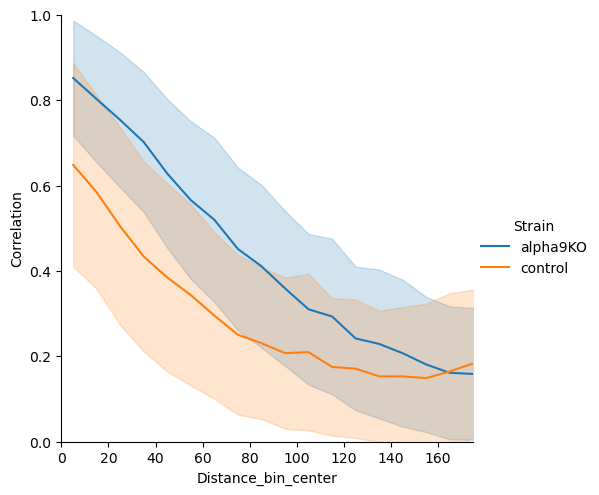

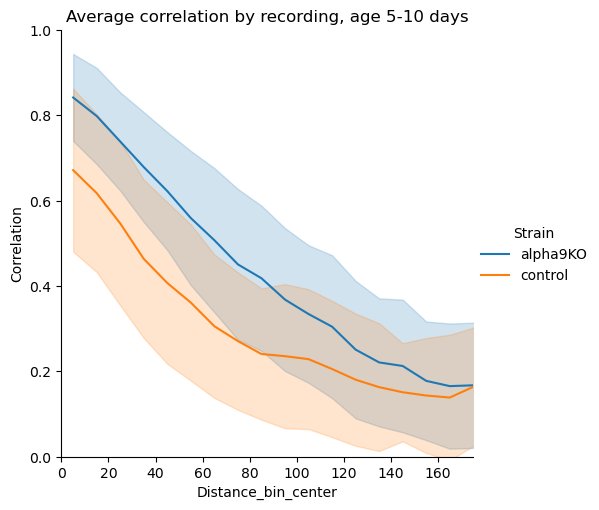

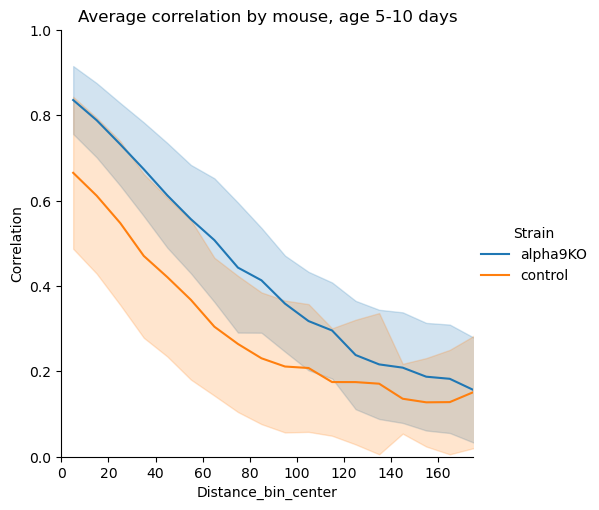

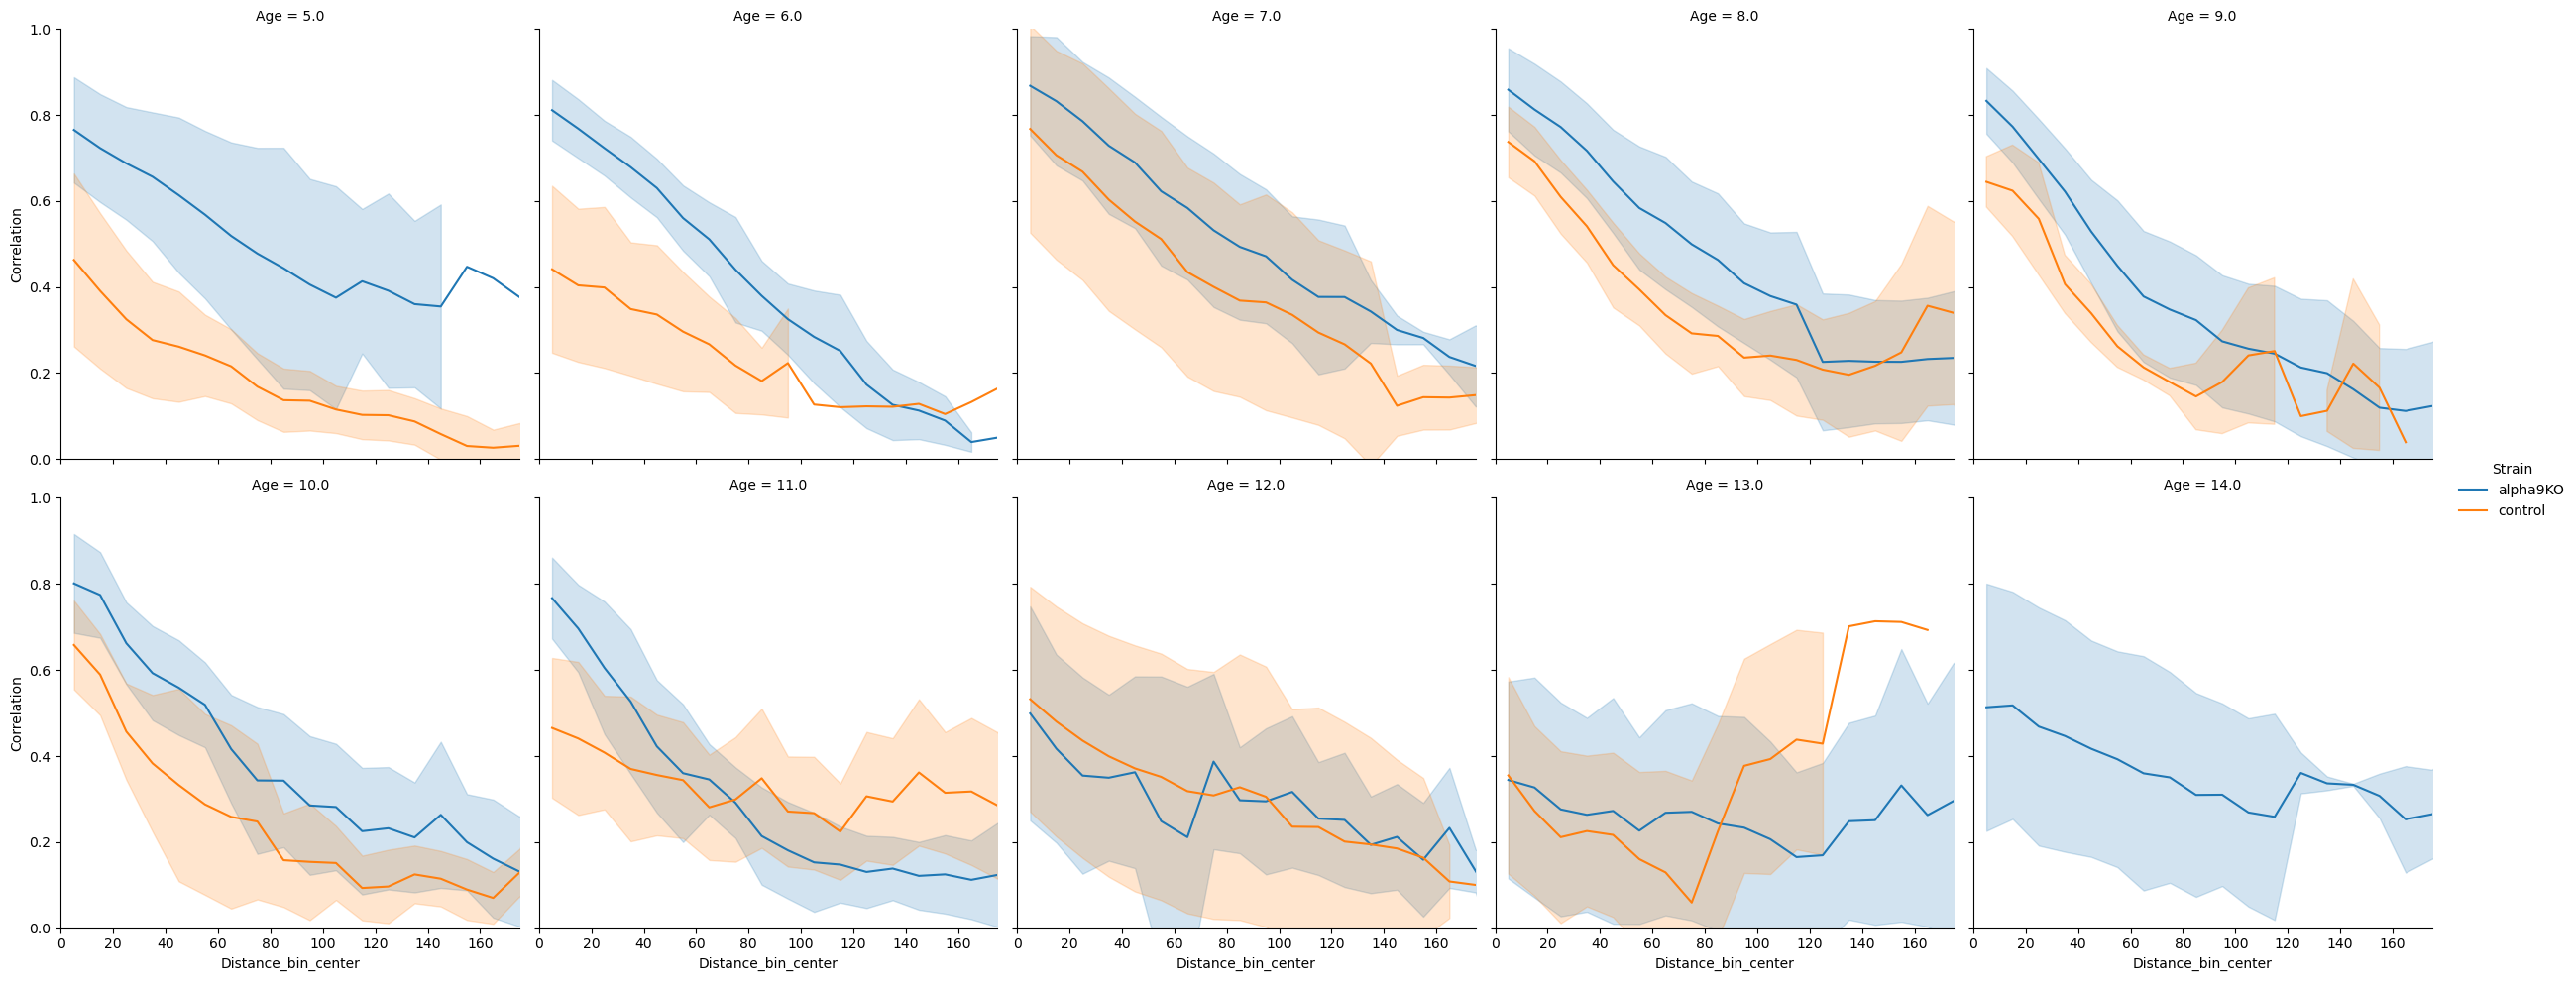

In [73]:
import seaborn as sns

age_min = 5
age_max = 10

sns.relplot(
    data=results_df[(results_df['Age']>=age_min) & (results_df['Age']<=age_max)],
    x='Distance_bin_center',
    hue='Strain',
    y='Correlation',
    kind='line',
    estimator=corrcoeff_mean,
    errorbar='sd'
 )
plt.ylim(0,1)
plt.xlim(0,175)

sns.relplot(
    data=results_df_avg[(results_df_avg['Age']>=age_min) & (results_df_avg['Age']<=age_max)],
    x='Distance_bin_center',
    hue='Strain',
    y='Correlation',
    kind='line',
    estimator=corrcoeff_mean,
    errorbar='sd'
 )
plt.ylim(0,1)
plt.xlim(0,175)
plt.title(f'Average correlation by recording, age {age_min}-{age_max} days')

sns.relplot(
    data=results_df_avg_by_mouse[(results_df_avg_by_mouse['Age']>=age_min) & (results_df_avg_by_mouse['Age']<=age_max)],
    x='Distance_bin_center',
    hue='Strain',
    y='Correlation',
    kind='line',
    estimator=corrcoeff_mean,
    errorbar='sd'
 )
plt.ylim(0,1)
plt.xlim(0,175)
plt.title(f'Average correlation by mouse, age {age_min}-{age_max} days')


sns.relplot(
    data=results_df_avg,
    x='Distance_bin_center',
    hue='Strain',
    y='Correlation',
    kind='line',
    estimator=corrcoeff_mean,
    errorbar='sd',
    col='Age',
    col_wrap=5
 )
plt.ylim(0,1)
plt.xlim(0,175)

In [74]:
import numpy as np
import statsmodels.formula.api as smf

d = results_df_avg_by_mouse[
    (results_df_avg_by_mouse["Age"] <= 10) &
    (results_df_avg_by_mouse["Age"] >= age_min) #&
    #(results_df_avg_by_mouse["Distance_bin_center"] <= 200)
].copy()

d["z_corr"] = np.arctanh(d["Correlation"].clip(-0.999999, 0.999999))
d = d[["z_corr", "Strain", "Distance_bin_center", "Mouse ID"]].dropna()

model = smf.mixedlm(
    "z_corr ~ C(Strain) + Distance_bin_center",
    data=d,
    groups=d["Mouse ID"]
).fit()

print(model.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       z_corr  
No. Observations:       855           Method:                   REML    
No. Groups:             52            Scale:                    0.0150  
Min. group size:        2             Log-Likelihood:           434.0393
Max. group size:        23            Converged:                Yes     
Mean group size:        16.4                                            
------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     1.110    0.038  29.245 0.000  1.036  1.185
C(Strain)[T.control]         -0.152    0.054  -2.814 0.005 -0.257 -0.046
Distance_bin_center[T.15.0]  -0.126    0.024  -5.229 0.000 -0.174 -0.079
Distance_bin_center[T.25.0]  -0.245    0.024 -10.147 0.000 -0.292 -0.

## Conclusions
There is a significant difference between WT and alpha9 ko as determined by a mixed linear model (P=0.005). This is calculated using the mouse as a unit. Similar conclusions if we use individual cells or recordings.

# Create the events df.
This is the Dataframe in which we callect 'events', defined as a calcium transients in more than one hair cells (i.e., a calcium wave). Each row represents one event.

How calcium spikes are combined in an event is defined in the global variables at the top of the cell. These are the same as 2025 Francesca's paper for consistency, even though on inspection I would have preferred other parameters. The results are the same with both sets of parameters though. 

In [36]:
from scipy.signal import savgol_filter, peak_widths
MAX_PEAK_DISTANCE = 2 #s # I prefer 5, 2 was what was used in Francesca's Nat Comm. I will stick to the previous value for now. 
MIN_CELLS = 3 # I prefer 4, but 3 was what was used in Franesca's nat comm Fig (3). 
MAX_CELL_SKIP = 4 # Francesca's Nat Comm. was 4.
PEAK_SEARCH_RADIUS = 20
TRACE_WINDOW_SECONDS = 10  # ±10 seconds around peak
BASELINE_WINDOW = (-7.5, -5)  # Time window (in seconds) for baseline calculation

COMMON_SAMPLING_RATE = 22.279  # Hz - common time grid for resampling 
# Create common time grid for interpolation
common_time_grid = np.arange(-TRACE_WINDOW_SECONDS, TRACE_WINDOW_SECONDS + 1/COMMON_SAMPLING_RATE, 1/COMMON_SAMPLING_RATE)

events_rows = []
trace_rows = []  # Store individual cell traces for each event
event_counter = 0  # Unique event ID across all folders

for j,cells in tqdm.tqdm(allcells.groupby('Folder'), total=allcells['Folder'].nunique()):
    max_peak_distance_frames = MAX_PEAK_DISTANCE * cells['fps'].iloc[0]
    folder = j
    traces = alltraces[cells['Cell ID']]

    traces = traces.apply(lambda x: savgol_filter(x, 11, 1), axis=0)
   
   # traces = traces.apply(lambda x: tu.rollingMedianCorrection(x, rollingN=2000) + x.iloc[0], axis=0)


    #Take all peaks from all cells in the recording, and create an "Event" with all the cells that respond within MAX_PEAK_DISTANCE seconds of each other.
    # Count each event once (e.g., when going through the peaks of another cells, don't count already counted events.). Events have to be a minimum of MIN_CELLS to be counted.
    
    fps = cells['fps'].iloc[0]
    age = cells['Age'].iloc[0]
    strain = cells['Strain'].iloc[0]
    mouse_id = cells['Mouse ID'].iloc[0]
    
    # Collect all (frame, cell_id, peak_value) entries across all cells
    all_peaks = []
    for _, row in cells.iterrows():
        cell_id = row['Cell ID']
        trace_z = tu.detrend_z_score(alltraces[cell_id].dropna(),rollingN = 2000,savgol_order=21) # recover the original trace used to detect peaks.
        for peak_frame in row['Peak positions']:
            peak_frame = int(peak_frame)
            left = max(0, peak_frame - PEAK_SEARCH_RADIUS)
            right = min(traces.shape[0] - 1, peak_frame + PEAK_SEARCH_RADIUS)
            local_window = traces.iloc[left:right + 1][cell_id]
            if local_window.empty:
                raise ValueError(f"Local window is empty for cell {cell_id} at peak frame {peak_frame}")
                continue

            real_peak_frame = int(local_window.idxmax())
            peak_value = float(local_window.max())
            peak_properties = peak_widths(trace_z, [peak_frame], rel_height=0.5)
            peak_width = peak_properties[0][0] / fps
            peak_left = peak_properties[2][0] 
            peak_right = peak_properties[3][0]

            peak_width_10 = peak_widths(trace_z, [peak_frame], rel_height=0.1)
            peak_width_50 = peak_widths(trace_z, [peak_frame], rel_height=0.5)
            #rise_time = (int(peak_width_10[2][0]) - int(peak_width_50[2][0])) / fps
            rise_time = (peak_frame - int(peak_width_50[2][0])) / fps
#            decay_time = (int(peak_width_50[3][0]) - int(peakistance bin'] == 50], hue = 'Strain', x = 'Peak value',  stat='percent')

            decay_time = (int(peak_width_50[3][0]) - peak_frame) / fps

            all_peaks.append({'frame': real_peak_frame, 'cell_id': cell_id, 'value': peak_value, 'width': peak_width, 'rise_time': rise_time, 'decay_time': decay_time,
                              'left_margin':peak_left,'right_margin':peak_right})
    
    if not all_peaks:
        continue
    
    all_peaks = sorted(all_peaks, key=lambda x: x['frame'])
    
    # Greedy clustering: group peaks within max_peak_distance_frames of the first peak in each cluster
    visited = [False] * len(all_peaks)
    for i, anchor in enumerate(all_peaks):
        if visited[i]:
            continue
        visited[i] = True
        event_peaks = [anchor]
        
        for j_peak in range(i + 1, len(all_peaks)):
            if all_peaks[j_peak]['frame'] - anchor['frame'] > max_peak_distance_frames:
                break
            if not visited[j_peak]:
                event_peaks.append(all_peaks[j_peak])
                visited[j_peak] = True
        
        # Per-cell max peak value (a cell may contribute multiple peaks)
        cell_max_values = {}
        for p in event_peaks:
            if p['cell_id'] not in cell_max_values or p['value'] > cell_max_values[p['cell_id']]:
                cell_max_values[p['cell_id']] = p['value']

        # ── OLD: single contiguity flag (kept for reference) ──────────────────
        # cell_indices = [int(c.split('_')[-1]) for c in cell_max_values.keys()]
        # cell_indices.sort()
        # cell_skips = np.diff(cell_indices)
        # if np.any(cell_skips > MAX_CELL_SKIP):
        #     contiguous = False
        # else:
        #     contiguous = True
        # ──────────────────────────────────────────────────────────────────────

        # NEW: split the greedy cluster into contiguous sub-events.
        # Sort cells by numeric index; start a new sub-event wherever the gap
        # between consecutive cell numbers exceeds MAX_CELL_SKIP.
        sorted_cells = sorted(cell_max_values.keys(), key=lambda c: int(c.split('_')[-1]))
        sub_event_groups = []
        current_group = [sorted_cells[0]]
        for k in range(1, len(sorted_cells)):
            prev_idx = int(sorted_cells[k - 1].split('_')[-1])
            curr_idx = int(sorted_cells[k].split('_')[-1])
            if curr_idx - prev_idx <= MAX_CELL_SKIP:
                current_group.append(sorted_cells[k])
            else:
                sub_event_groups.append(current_group)
                current_group = [sorted_cells[k]]
        sub_event_groups.append(current_group)

        # Pre-compute recording border indices (shared across sub-events)
        cell_indices_all = [int(c.split('_')[-1]) for c in cells['Cell ID']]
        min_cell_index   = min(cell_indices_all)
        max_cell_index   = max(cell_indices_all)

        # Process each contiguous sub-event independently
        for sub_cell_ids in sub_event_groups:
            sub_cell_max_values = {c: cell_max_values[c] for c in sub_cell_ids}

            # Discard sub-events that don't meet the minimum cell threshold
            if len(sub_cell_max_values) < MIN_CELLS:
                continue

            # Only keep peaks belonging to this sub-event's cells
            sub_event_peaks = [p for p in event_peaks if p['cell_id'] in sub_cell_max_values]

            sub_cell_indices     = [int(c.split('_')[-1]) for c in sub_cell_ids]
            reached_left_border  = min_cell_index in sub_cell_indices
            reached_right_border = max_cell_index in sub_cell_indices

            events_rows.append({
                'Folder': folder,
                'Age': age,
                'Strain': strain,
                'Mouse ID': mouse_id,
                'Time (frame)': np.mean([p['frame'] for p in sub_event_peaks]),
                'Cells': len(sub_cell_max_values),
                'Cell IDs': list(sub_cell_max_values.keys()),
                'Peak values': list(sub_cell_max_values.values()),
                'Peak widths': [p['width'] for p in sub_event_peaks],
                'Peak left margin':  [p['left_margin']  for p in sub_event_peaks],
                'Peak right margin': [p['right_margin'] for p in sub_event_peaks],
                'Rise times':  [p['rise_time']  for p in sub_event_peaks],
                'Decay times': [p['decay_time'] for p in sub_event_peaks],
                'Total cells': len(cells),
                'Contiguous': True,  # by construction every sub-event is contiguous
                'Reached left border':  reached_left_border,
                'Reached right border': reached_right_border,
                'Independent recordings ID': cells['Independent recordings ID'].iloc[0],
                'Recording duration': cells['Recording duration'].iloc[0],
            })

            # ── Extract trace windows for this sub-event ──────────────────────
            window_frames = int(TRACE_WINDOW_SECONDS * fps)
            max_cell_id   = max(sub_cell_max_values, key=sub_cell_max_values.get)

            # Map each cell to the frame of its highest peak in this sub-event
            cell_to_peak_frame = {}
            for p in sub_event_peaks:
                if p['cell_id'] in sub_cell_max_values:
                    if p['cell_id'] not in cell_to_peak_frame or p['value'] == sub_cell_max_values[p['cell_id']]:
                        cell_to_peak_frame[p['cell_id']] = p['frame']

            resampled_traces_for_avg = []

            for cell_id in sub_cell_max_values.keys():
                if cell_id not in cell_to_peak_frame:
                    continue

                peak_frame = cell_to_peak_frame[cell_id]
                left  = max(0, peak_frame - window_frames)
                right = min(traces.shape[0] - 1, peak_frame + window_frames)

                trace_segment = traces.iloc[left:right + 1][cell_id].values
                frame_indices = np.arange(left, right + 1)
                time_rel      = (frame_indices - peak_frame) / fps

                trace_resampled = np.interp(common_time_grid, time_rel, trace_segment)
                resampled_traces_for_avg.append(trace_resampled)

                for t_val, signal_val in zip(common_time_grid, trace_resampled):
                    trace_rows.append({
                        'Event ID': event_counter,
                        'Cell ID':  cell_id,
                        'Time (s)': t_val,
                        'Signal':   signal_val,
                        'Is max peak': (cell_id == max_cell_id),
                        'Strain':   strain,
                        'Age':      age,
                        'Mouse ID': mouse_id,
                        'Folder':   folder
                    })

            # Event-average trace (baseline-subtracted)
            if resampled_traces_for_avg:
                avg_trace     = np.mean(resampled_traces_for_avg, axis=0)
                baseline_mask = (common_time_grid >= BASELINE_WINDOW[0]) & (common_time_grid <= BASELINE_WINDOW[1])
                if np.any(baseline_mask):
                    baseline  = np.mean(avg_trace[baseline_mask])
                    avg_trace = avg_trace - baseline
                for t_val, signal_val in zip(common_time_grid, avg_trace):
                    trace_rows.append({
                        'Event ID': event_counter,
                        'Cell ID':  'Event average',
                        'Time (s)': t_val,
                        'Signal':   signal_val,
                        'Is max peak': False,
                        'Strain':   strain,
                        'Age':      age,
                        'Mouse ID': mouse_id,
                        'Folder':   folder
                    })

            event_counter += 1

events_df = pd.DataFrame(events_rows)


#We use the median to define the duration of the event
events_df['Max peak value'] = events_df['Peak values'].apply(lambda x: np.max(x))
events_df['Average peak width'] = events_df['Peak widths'].apply(lambda widths: np.median(widths) if isinstance(widths, list) and len(widths) > 0 else np.nan)
events_df['Average rise time'] = events_df['Rise times'].apply(lambda widths: np.median(widths) if isinstance(widths, list) and len(widths) > 0 else np.nan)
events_df['Average decay time'] = events_df['Decay times'].apply(lambda widths: np.median(widths) if isinstance(widths, list) and len(widths) > 0 else np.nan)


#Define age groups for events_df
events_df['Age group'] = pd.cut(events_df['Age'], bins=[4, 10,12,14], labels=['5-10', '11-12', '13-14'])
#check
events_df.groupby('Age')['Age group'].first()

print(events_df.shape)
#print((events_df['Max peak value']>1).sum())
#events_df = events_df[events_df['Max peak value']>3].reset_index(drop=True)


events_traces_df = pd.DataFrame(trace_rows)

print(f"Total events detected: {len(events_df)}")
print(f"Total trace data points stored: {len(events_traces_df)}")
print(f"Number of unique event IDs: {events_traces_df['Event ID'].nunique()}")
print(f"Common time grid: {len(common_time_grid)} points at {COMMON_SAMPLING_RATE} Hz sampling rate")
print(f"Time range: [{common_time_grid[0]:.2f}, {common_time_grid[-1]:.2f}] seconds")


100%|██████████| 412/412 [00:40<00:00, 10.18it/s]


(2883, 24)
Total events detected: 2883
Total trace data points stored: 9740577
Number of unique event IDs: 2883
Common time grid: 447 points at 22.279 Hz sampling rate
Time range: [-10.00, 10.02] seconds


## Combine by mouse
Usual averaging events by mouse. `Cells` is the number of cells in an event. 

We also create an "only contained events" df. In this DataFrame, events that reach a border (the first or last cells in view), are marked accordingly. The idea is to discard from the number of cells calculation these events, as they likely underestimate the size of the events. However, conclusions do not change by removing them or not, so we may keep them in the end to avoid overcomplication. We should still include events that reach both left AND right border, as these are just large events, even if the go beyond the field of view (we will underestimate these events in any recording condition.)

In [37]:
events_df_averaged_by_mouse = events_df.groupby(['Mouse ID']).agg({
    'Cells': 'mean',
    'Max peak value': 'mean',
    'Age': 'first',
    'Strain': 'first',
    'Age group': 'first',
    'Average peak width': 'mean',
    'Average rise time': 'mean',
    'Average decay time': 'mean',
    'Reached left border': 'mean',
    'Reached right border': 'mean',
}).reset_index()

#We consider only the waves that do not touch either borders. Either they touch none, or they touch both to be considered.
events_df_only_contained = events_df[events_df['Reached left border']==  events_df['Reached right border']]
events_df_averaged_by_mouse_only_contained = events_df_only_contained.groupby(['Mouse ID']).agg({
    'Cells': 'mean',
    'Max peak value': 'mean',
    'Age': 'first', 
    'Strain': 'first',
    'Age group': 'first',
    'Average peak width': 'mean',
    'Average rise time': 'mean',
    'Average decay time': 'mean',
}).reset_index()

## How many mice per age/age group and strain actually have events?

In [38]:
mouse_has_events_df = []

for mouse in allcells['Mouse ID'].unique():
    strain = allcells[allcells['Mouse ID']==mouse]['Strain'].iloc[0]
    age = allcells[allcells['Mouse ID']==mouse]['Age'].iloc[0]
    if mouse not in events_df['Mouse ID'].unique():
        print(f"Mouse {mouse} (Age: {age}, Strain: {strain}) has no detected events.")
        mousehasevents = False
    else:
        mousehasevents = True
    mouse_has_events_df.append({
        'Mouse ID': mouse,
        'Strain': strain,
        'Age': age,
        'Has events': mousehasevents
    })
mouse_has_events_df = pd.DataFrame(mouse_has_events_df)
mouse_has_events_df['Age group'] = pd.cut(mouse_has_events_df['Age'], bins=[4, 10,12,14], labels=['5-10', '11-12', '13-14'])


Mouse 36 (Age: 12, Strain: alpha9KO) has no detected events.
Mouse 129 (Age: 12, Strain: control) has no detected events.
Mouse 16 (Age: 13, Strain: alpha9KO) has no detected events.
Mouse 112 (Age: 13, Strain: control) has no detected events.
Mouse 113 (Age: 13, Strain: control) has no detected events.
Mouse 114 (Age: 13, Strain: control) has no detected events.
Mouse 120 (Age: 13, Strain: control) has no detected events.
Mouse 121 (Age: 13, Strain: control) has no detected events.


In [42]:
mouse_has_events_df_by_age = mouse_has_events_df.groupby(['Strain', 'Age']).agg({'Has events': 'sum', 'Mouse ID': 'count'}).reset_index().rename(columns={'Has events': 'Mice with events', 'Mouse ID': 'Total mice'})
mouse_has_events_df_by_age['Fraction with events'] = mouse_has_events_df_by_age['Mice with events'] / mouse_has_events_df_by_age['Total mice']
mouse_has_events_df_by_age.pivot(index='Age', columns='Strain', values=['Total mice', 'Mice with events', 'Fraction with events'])

Total mice         Mice with events         Fraction with events  \
Strain   alpha9KO control         alpha9KO control             alpha9KO   
Age                                                                       
5             2.0     3.0              2.0     3.0             1.000000   
6             3.0     2.0              3.0     2.0             1.000000   
7             7.0     6.0              7.0     6.0             1.000000   
8             8.0     3.0              8.0     3.0             1.000000   
9             6.0     4.0              6.0     4.0             1.000000   
10            5.0     3.0              5.0     3.0             1.000000   
11            4.0     3.0              4.0     3.0             1.000000   
12            3.0     4.0              2.0     3.0             0.666667   
13            3.0     6.0              2.0     1.0             0.666667   
14            1.0     NaN              1.0     NaN             1.000000   

                  
Strain   control  
Age               
5       1.000000  
6       1.000000  
7       1.000000  
8       1.000000  
9       1.000000  
10      1.000000  
11      1.000000  
12      0.750000  
13      0.166667  
14           NaN

In the P13-14 group, only 1 out of 6 control mice showed coordinated events, while 3 out of 4 alpha9ko did. 

More specifically, at P13, 2/3 alpha9 and 1/6 control had events.
We need to check that this is not all random matching.

At P11-12, 6/7 alpha9 and controls showed coordinated activity.


## Events Frequency

It would be interesting to look at the frequency of just these big events, as it "appears" bigger by eye than the single cell frequency we calculated above.

(After analysis: it isn't).

In [43]:

#To calculate frequencies, first we combine by independent recording, so that we don't count the same area as a replicate.
events_df_combined = events_df.groupby(['Independent recordings ID']).agg({'Cells':'count','Strain':'first','Age':'first','Age group':'first','Mouse ID':'first'}).reset_index().rename(columns={'Cells':'Total number of events'})

#Determine the total duration of each recording
events_df_combined['Recording duration'] = None
for rid, group in allcells_combined.groupby('Independent recordings ID'):
    group_allcells = allcells[allcells['Independent recordings ID']==rid]

    events_df_combined.loc[events_df_combined['Independent recordings ID']==rid, 'Recording duration'] = group_allcells['Recording duration'].unique().sum()
    
events_df_combined['Event frequency (1/min)'] = events_df_combined['Total number of events']/events_df_combined['Recording duration']*60

events_df_combined_avg_by_mouse = events_df_combined.groupby(['Mouse ID']).agg({'Event frequency (1/min)':'mean','Age':'first','Age group':'first','Strain':'first','Total number of events':'sum'}).reset_index().rename(columns={'Total number of events':'Total number of events across recordings'})



Text(9.444444444444445, 0.5, 'Frequency of multi-cell events (1/min)')

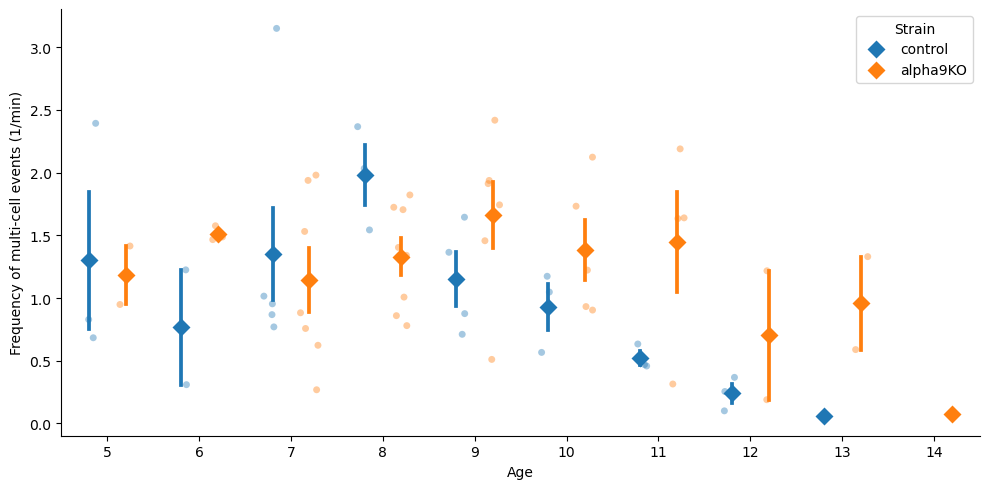

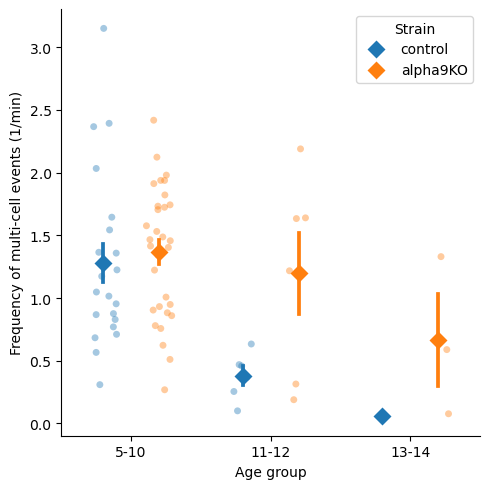

In [44]:
sns.catplot(data=events_df_combined_avg_by_mouse[(events_df_combined_avg_by_mouse['Age']>=5 )& (events_df_combined_avg_by_mouse['Age']<=15)],x= 'Age',hue = 'Strain',y='Event frequency (1/min)',kind= 'strip',
            dodge=0.4, alpha=0.4,hue_order = ['control','alpha9KO'],jitter=0.2,aspect=2,legend=False)

sns.pointplot(data=events_df_combined_avg_by_mouse[(events_df_combined_avg_by_mouse['Age']>=5 )& (events_df_combined_avg_by_mouse['Age']<=15)],x= 'Age',hue = 'Strain',y='Event frequency (1/min)',
              dodge=0.4, errorbar='se',markers='D',linestyles='none',hue_order = ['control','alpha9KO'])
plt.ylabel('Frequency of multi-cell events (1/min)')

sns.catplot(data=events_df_combined_avg_by_mouse[(events_df_combined_avg_by_mouse['Age']>=5 )& (events_df_combined_avg_by_mouse['Age']<=15)],x= 'Age group',hue = 'Strain',y='Event frequency (1/min)',kind= 'strip',
            dodge=0.4, alpha=0.4,hue_order = ['control','alpha9KO'],jitter=0.2,legend=False)

sns.pointplot(data=events_df_combined_avg_by_mouse[(events_df_combined_avg_by_mouse['Age']>=5 )& (events_df_combined_avg_by_mouse['Age']<=15)],x= 'Age group',hue = 'Strain',y='Event frequency (1/min)',
              dodge=0.4, errorbar='se',markers='D',linestyles='none',hue_order = ['control','alpha9KO'])
plt.ylabel('Frequency of multi-cell events (1/min)')

In [45]:
#Anova to test differences plus paired mann-withney with holm-bonferroni correction for multiple comparisons
anova_df = events_df_combined_avg_by_mouse[
    ['Event frequency (1/min)', 'Age', 'Strain', 'Age group']
].dropna().copy()
anova_df.rename(columns={'Event frequency (1/min)':'Fop'}, inplace=True)    


anova_df = anova_df[anova_df['Age']<=15]

# Force dependent variable to numeric
anova_df['Fop'] = pd.to_numeric(anova_df['Fop'], errors='coerce')

# Drop rows where any needed value is missing
anova_df = anova_df.dropna(subset=['Fop', 'Age', 'Strain'])

# Treat predictors as categorical factors
anova_df['Age'] = anova_df['Age'].astype('category')
anova_df['Agegroup'] = pd.cut(anova_df['Age'], bins=[4, 10,12,14], labels=['5-10', '11-12', '13-14'])
anova_df['Agegroup'] = anova_df['Agegroup'].values.astype(str)
anova_df['Strain'] = anova_df['Strain'].astype('category')

# Two-way ANOVA with Age, Strain, and Age x Strain interaction
model = ols(
    'Fop ~ C(Agegroup) * C(Strain)',
    data=anova_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
anova_table




,sum_sq,df,F,PR(>F)
C(Agegroup),4.808757,2.0,6.693101,0.002334
C(Strain),0.987294,1.0,2.748342,0.102407
C(Agegroup):C(Strain),1.388479,2.0,1.932563,0.153398
Residual,22.272410,62.0,NaN,NaN


### Conclusions
No difference exist on the frequency of coordinated events between strains P=0.102. This is consistent with what we saw for ca waves.

## Number of cells
Here, we can consider only the Contaiend events, meaning: either the event is all within the frame, or it is touching both ends. 
This involve using the events_df_averaged_by_mouse_only_contained dataframe and the events_df_only_contained (for average by mouse and single events, respectively).
The conclusions do not seem to be different.

Text(0.5, 1.0, 'Average number of cells per event per mouse, all events')

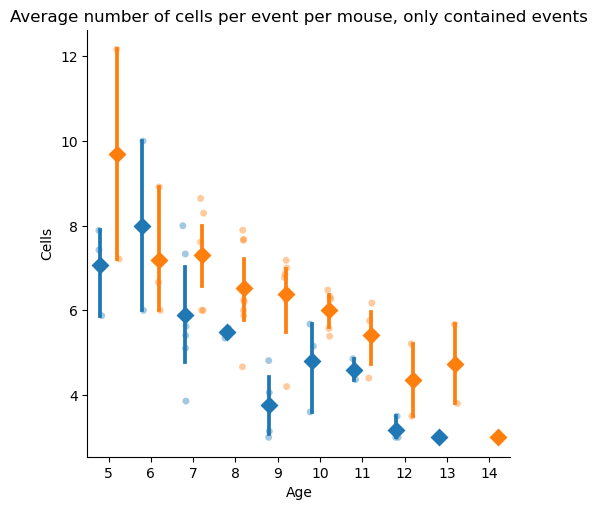

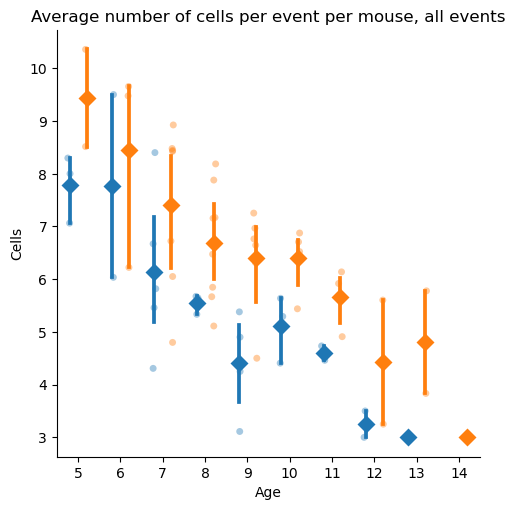

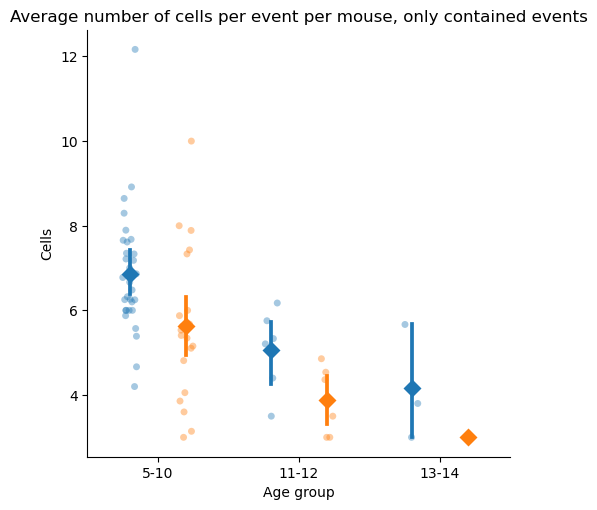

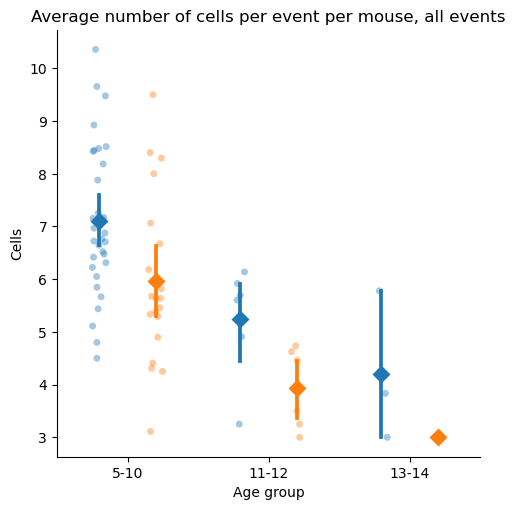

In [46]:
g = sns.catplot(data=events_df_averaged_by_mouse_only_contained[(events_df_averaged_by_mouse_only_contained['Age']>=5 )& (events_df_averaged_by_mouse_only_contained['Age']<=15)],
                x= 'Age',y='Cells',hue='Strain',kind= 'strip',errorbar='sd',alpha = .4, dodge=True,legend=False)
plt.title('Average number of cells per event per mouse, only contained events')
sns.pointplot(data=events_df_averaged_by_mouse_only_contained[(events_df_averaged_by_mouse_only_contained['Age']>=5 )& (events_df_averaged_by_mouse_only_contained['Age']<=15)],
              x= 'Age',y='Cells',hue='Strain',ax=g.ax,legend=False,dodge=0.4,   markers="D",linestyles="none",)
plt.title('Average number of cells per event per mouse, only contained events')

g = sns.catplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=15)],
                x= 'Age',y='Cells',hue='Strain',kind= 'strip',errorbar='sd',alpha = .4, dodge=True,legend=False)
plt.title('Average number of cells per event per mouse, all events')
sns.pointplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=15)],
              x= 'Age',y='Cells',hue='Strain',ax=g.ax,legend=False,dodge=0.4,   markers="D",linestyles="none",)
plt.title('Average number of cells per event per mouse, all events')

g = sns.catplot(data=events_df_averaged_by_mouse_only_contained[(events_df_averaged_by_mouse_only_contained['Age']>=5 )& (events_df_averaged_by_mouse_only_contained['Age']<=15)],
                x= 'Age group',y='Cells',hue='Strain',kind= 'strip',errorbar='sd',alpha = .4, dodge=True,legend=False)
plt.title('Average number of cells per event per mouse, only contained events') 
sns.pointplot(data=events_df_averaged_by_mouse_only_contained[(events_df_averaged_by_mouse_only_contained['Age']>=5 )& (events_df_averaged_by_mouse_only_contained['Age']<=15)],
              x= 'Age group',y='Cells',hue='Strain',ax=g.ax,legend=False,dodge=0.4,   markers="D",linestyles="none",)
plt.title('Average number of cells per event per mouse, only contained events')


g = sns.catplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=15)],
                x= 'Age group',y='Cells',hue='Strain',kind= 'strip',errorbar='sd',alpha = .4, dodge=True,legend=False)
plt.title('Average number of cells per event per mouse, all events')
sns.pointplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=15)],
              x= 'Age group',y='Cells',hue='Strain',ax=g.ax,legend=False,dodge=0.4,   markers="D",linestyles="none",)
plt.title('Average number of cells per event per mouse, all events')



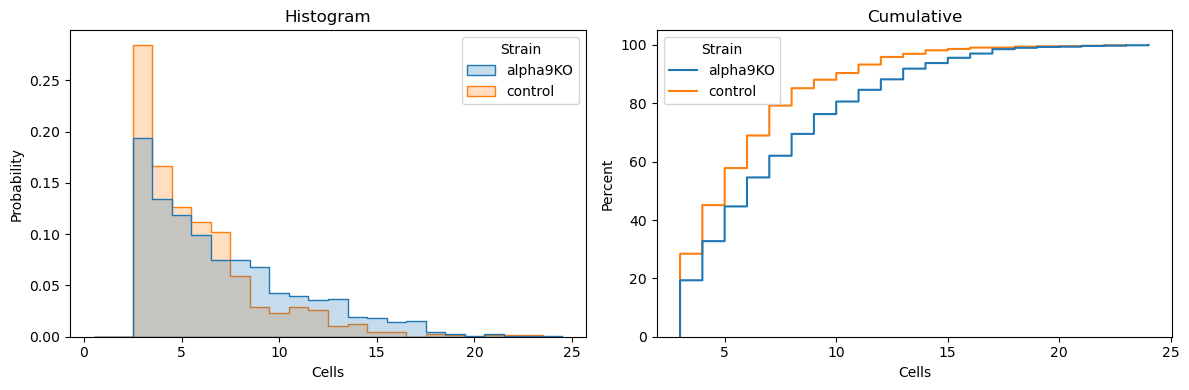

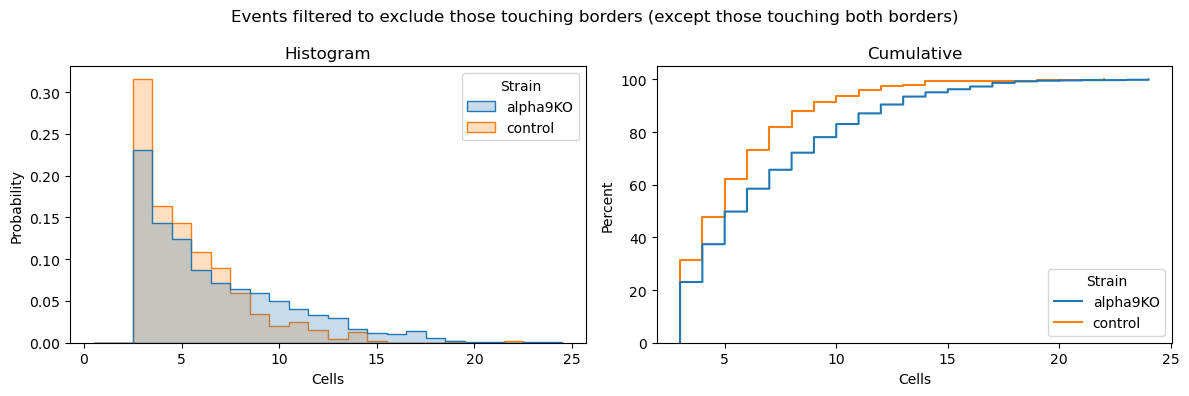

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(data=events_df[events_df['Age'].between(5, 10)], x='Cells', hue='Strain', element='step', stat='probability', common_norm=False,bins=np.arange(0.5, events_df['Cells'].max() + 1.5, 1), ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cells')

# Right: cumulative
sns.ecdfplot(
    data=events_df[events_df['Age'].between(5, 10)],
    x='Cells',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)
axes[1].set_title('Cumulative')
axes[1].set_xlabel('Cells')

plt.tight_layout()
plt.show()



#Do not consider events that touch the borders, unless they touch both borders, in which case we keep them because they are likely to be true large events that just happen to have the origin near the border.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(data=events_df_only_contained[events_df_only_contained['Age'].between(5, 10)], x='Cells', hue='Strain', element='step', stat='probability', common_norm=False,bins=np.arange(0.5, events_df_only_contained['Cells'].max() + 1.5, 1), ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cells')

# Right: cumulative
sns.ecdfplot(
    data=events_df_only_contained[events_df_only_contained['Age'].between(5, 10)],
    x='Cells',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)

#sns.histplot(data=events_df_filtered, x='Cells', hue='Strain', element='step', stat='probability', common_norm=False,bins=np.arange(0.5, events_df_filtered['Cells'].max() + 1.5, 1), cumulative=True, ax=axes[1])
axes[1].set_title('Cumulative')
axes[1].set_xlabel('Cells')
plt.suptitle('Events filtered to exclude those touching borders (except those touching both borders)')
plt.tight_layout()
plt.show()



## Statistical tests and conclusion for number of cells per event (event size)
Within each age group, event size was compared between strains using a linear mixed-effects model with mouse as a random effect. P-values from the three age-group comparisons were corrected using Holm-Bonferroni.

In [48]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

anova_df = events_df_only_contained[
    ["Cells", "Age", "Strain", "Mouse ID"]
].dropna().copy()

anova_df = anova_df.rename(columns={"Cells": "Fop"})

anova_df["Fop"] = pd.to_numeric(anova_df["Fop"], errors="coerce")
anova_df["Age"] = pd.to_numeric(anova_df["Age"], errors="coerce")

anova_df = anova_df.dropna(subset=["Fop", "Age", "Strain", "Mouse ID"])
anova_df = anova_df[anova_df["Age"] <= 15]

anova_df["Agegroup"] = pd.cut(
    anova_df["Age"],
    bins=[4, 10, 12, 15],
    labels=["5-10", "11-12", "13-15"]
)

#Define the reference strain : P5-10 Control
anova_df["Agegroup"] = pd.Categorical(
    anova_df["Agegroup"],
    categories=["5-10", "11-12", "13-15"],
    ordered=True
)

anova_df["Strain"] = pd.Categorical(
    anova_df["Strain"],
    categories=["control", "alpha9KO"],   # first one is reference
    ordered=True
)

anova_df["Age"] = pd.Categorical(
    anova_df["Age"],
    categories=sorted(anova_df["Age"].unique()),
    ordered=True
)

# model = smf.mixedlm(
#     "Fop ~ C(Agegroup) * C(Strain)",
#     data=anova_df,
#     groups=anova_df["Mouse ID"]
# ).fit()

# print(model.summary())

#anova_df = anova_df[anova_df["Age"]<=10]
age_order = ["5-10", "11-12", "13-15"]
#age_order = sorted(anova_df["Age"].unique())
p_values = []
for ref_age in age_order:
    new_order = [ref_age] + [a for a in age_order if a != ref_age]

    anova_df["Agegroup_ref"] = pd.Categorical(
        anova_df["Agegroup"],
        categories=new_order,
        ordered=True
    )

    model = smf.mixedlm(
        "Fop ~ C(Agegroup_ref) * C(Strain)",
        data=anova_df,
        groups=anova_df["Mouse ID"]
    ).fit()
    pvalue = float(model.summary().tables[1].loc["C(Strain)[T.alpha9KO]"]['P>|z|']) 
    p_values.append((ref_age, pvalue))
    print("\nReference age:", ref_age)
    print(model.summary().tables[1].loc["C(Strain)[T.alpha9KO]"])

adjusted_p_values = multipletests([p for _, p in p_values], method='holm')[1]
for (ref_age, pvalue), adj_p in zip(p_values, adjusted_p_values):
    print(f"Reference age: {ref_age}, original p-value: {pvalue:.4f}, adjusted p-value: {adj_p:.4f}")


Reference age: 5-10
Coef.       1.405
Std.Err.    0.288
z           4.873
P>|z|       0.000
[0.025      0.840
0.975]      1.971
Name: C(Strain)[T.alpha9KO], dtype: object

Reference age: 11-12
Coef.        1.119
Std.Err.     0.672
z            1.664
P>|z|        0.096
[0.025      -0.199
0.975]       2.436
Name: C(Strain)[T.alpha9KO], dtype: object

Reference age: 13-15
Coef.        1.499
Std.Err.     3.487
z            0.430
P>|z|        0.667
[0.025      -5.337
0.975]       8.334
Name: C(Strain)[T.alpha9KO], dtype: object
Reference age: 5-10, original p-value: 0.0000, adjusted p-value: 0.0000
Reference age: 11-12, original p-value: 0.0960, adjusted p-value: 0.1920
Reference age: 13-15, original p-value: 0.6670, adjusted p-value: 0.6670


### Conclusions 
There is a significant difference between alpha9 and control in the number of cells in a calcium wave. This is true both if we group by individual ages and grouped ages. 
By grouped ages, the post-test is significant at P5-10 (P=0.0028) and not at the other ages.

## Duration

### Average traces and individual events
We can present an average "event shape" trace

Comparing 2376 events between strains (Age 5-10)
Strain distribution: {'alpha9KO': 1722, 'control': 654}


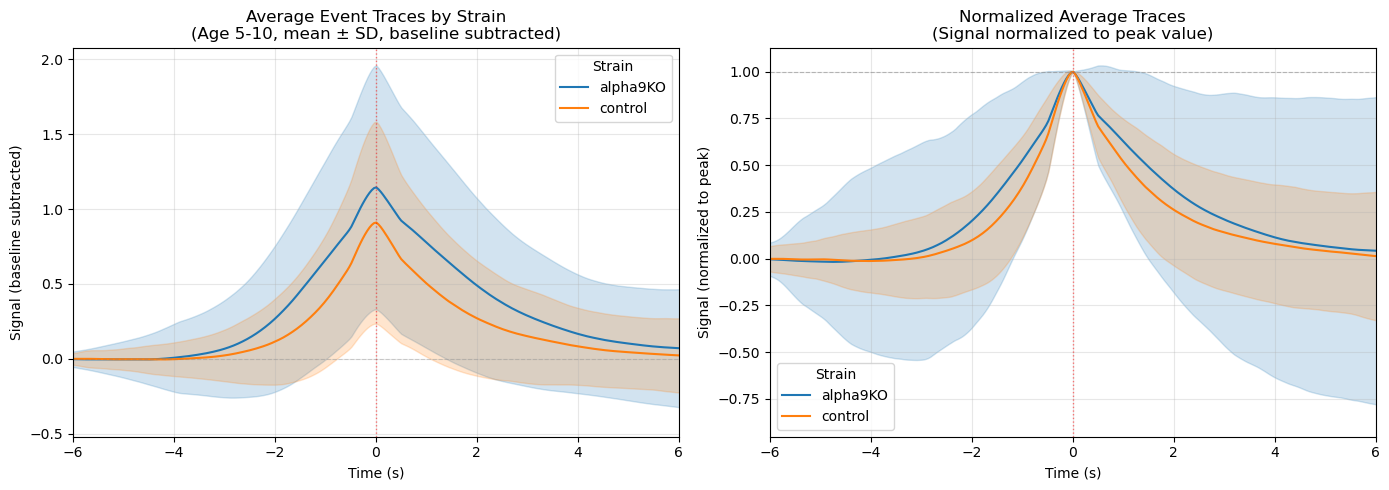

In [52]:
# Compare average event traces between strains using seaborn
# Filter for specific age range and use event averages only
age_min, age_max = 5,10

#Select only events that reach a certain value at t=0
#selected_events = events_traces_df[(events_traces_df['Signal']>1) & ( abs(events_traces_df['Time (s)'])<1/COMMON_SAMPLING_RATE)]['Event ID'].unique()

avg_traces_only = events_traces_df[
    #(events_traces_df['Is max peak'] == True) &
    (events_traces_df['Cell ID'] == 'Event average') &
    (events_traces_df['Age'] >= age_min) &
    (events_traces_df['Age'] <= age_max) 
 #   (events_traces_df['Event ID'].isin(selected_events))
].copy()

print(f"Comparing {avg_traces_only['Event ID'].nunique()} events between strains (Age {age_min}-{age_max})")
print(f"Strain distribution: {avg_traces_only.groupby('Strain')['Event ID'].nunique().to_dict()}")

# Plot 1: Average event traces by strain
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Direct comparison, all events
sns.lineplot(
    data=avg_traces_only,
    x='Time (s)',
    y='Signal',
    hue='Strain',
    estimator='mean',
    errorbar='sd',
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle=':', linewidth=1, alpha=0.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
axes[0].set_title(f'Average Event Traces by Strain\n(Age {age_min}-{age_max}, mean ± SD, baseline subtracted)')
axes[0].set_ylabel('Signal (baseline subtracted)')
axes[0].set_xlim(-6,6)
axes[0].grid(alpha=0.3)

# Right: Normalized to peak (t=0)
# For each event, normalize signal to value at t=0
normalized_traces = []
for event_id in avg_traces_only['Event ID'].unique():
    event_trace = avg_traces_only[avg_traces_only['Event ID'] == event_id].copy()
    # Find signal value closest to t=0
    zero_idx = (event_trace['Time (s)'] - 0).abs().idxmin()
    peak_signal = event_trace.loc[zero_idx, 'Signal']
   # min_signal = event_trace.loc[:,'Signal'].min()
    if peak_signal != 0:
        event_trace['Signal normalized'] = (event_trace['Signal']) / (peak_signal)
        normalized_traces.append(event_trace)

if normalized_traces:
    normalized_df = pd.concat(normalized_traces, ignore_index=True)
    sns.lineplot(
        data=normalized_df,
        x='Time (s)',
        y='Signal normalized',
        hue='Strain',
        estimator='mean',
        errorbar='sd',
        ax=axes[1]
    )
    axes[1].axvline(0, color='red', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title(f'Normalized Average Traces\n(Signal normalized to peak value)')
    axes[1].set_ylabel('Signal (normalized to peak)')
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(-6,6)
plt.tight_layout()
plt.show()

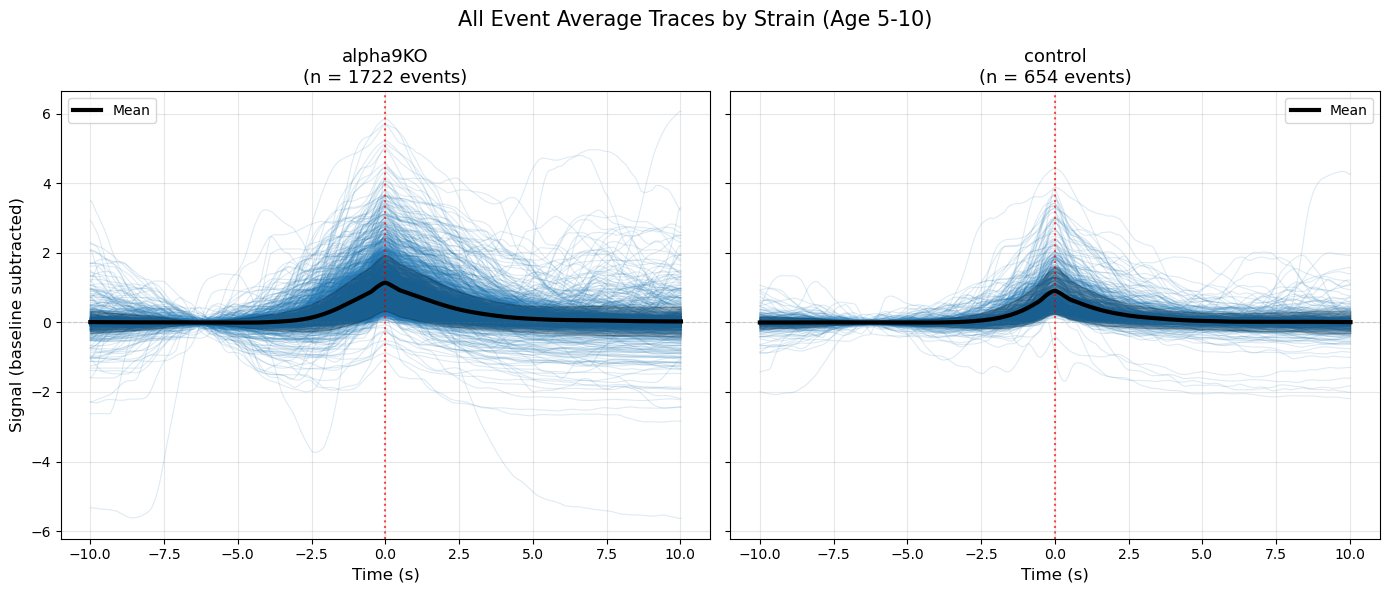

Total events plotted: 2376
Events per strain: {'alpha9KO': 1722, 'control': 654}


In [53]:
# Plot all individual event average traces, grouped by strain
age_min, age_max = 5, 10

# Filter for event averages only
avg_events = events_traces_df[
    (events_traces_df['Cell ID'] == 'Event average') &
    (events_traces_df['Age'] >= age_min) &
    (events_traces_df['Age'] <= age_max)
].copy()

strains = sorted(avg_events['Strain'].unique())
n_strains = len(strains)

fig, axes = plt.subplots(1, n_strains, figsize=(7 * n_strains, 6), sharey=True)
if n_strains == 1:
    axes = [axes]

for ax, strain_name in zip(axes, strains):
    strain_data = avg_events[avg_events['Strain'] == strain_name]
    n_events = strain_data['Event ID'].nunique()
    
    # Plot each individual event average trace
    for event_id in strain_data['Event ID'].unique():
        event_trace = strain_data[strain_data['Event ID'] == event_id].sort_values('Time (s)')
        ax.plot(event_trace['Time (s)'], event_trace['Signal'], 
                alpha=0.15, linewidth=0.8, color='tab:blue')
    
    # Overlay the overall mean
    mean_trace = strain_data.groupby('Time (s)')['Signal'].mean().reset_index()
    std_trace = strain_data.groupby('Time (s)')['Signal'].std().reset_index()
    
    ax.plot(mean_trace['Time (s)'], mean_trace['Signal'], 
            color='black', linewidth=3, label='Mean', zorder=10)
    ax.fill_between(mean_trace['Time (s)'], 
                     mean_trace['Signal'] - std_trace['Signal'], 
                     mean_trace['Signal'] + std_trace['Signal'],
                     color='black', alpha=0.2, zorder=9)
    
    ax.axvline(0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
    ax.set_xlabel('Time (s)', fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel('Signal (baseline subtracted)', fontsize=12)
    ax.set_title(f'{strain_name}\n(n = {n_events} events)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(f'All Event Average Traces by Strain (Age {age_min}-{age_max})', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

print(f"Total events plotted: {avg_events['Event ID'].nunique()}")
print(f"Events per strain: {avg_events.groupby('Strain')['Event ID'].nunique().to_dict()}")

(0.0, 9.536162570000792)

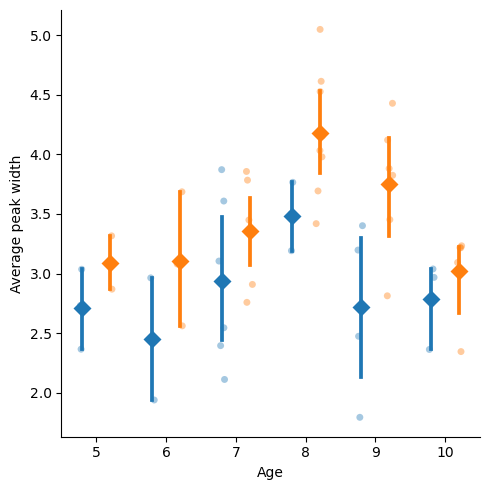

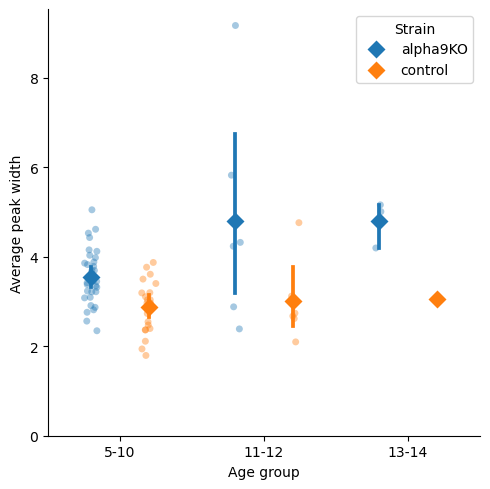

In [55]:

g = sns.catplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=10)],x= 'Age',y='Average peak width',hue='Strain',kind= 'strip',errorbar='sd',alpha = .4, dodge=True,legend=False)
sns.pointplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=10)],x= 'Age',y='Average peak width',hue='Strain',ax=g.ax,legend=False,dodge=0.4,   markers="D",linestyles="none",)


g = sns.catplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=15)],x= 'Age group',y='Average peak width',hue='Strain',kind= 'strip',errorbar='sd',alpha = .4, dodge=True,legend=False)
sns.pointplot(data=events_df_averaged_by_mouse[(events_df_averaged_by_mouse['Age']>=5 )& (events_df_averaged_by_mouse['Age']<=15)],x= 'Age group',y='Average peak width',hue='Strain',ax=g.ax,legend=True,dodge=0.4,   markers="D",linestyles="none",)
plt.ylim(0,)

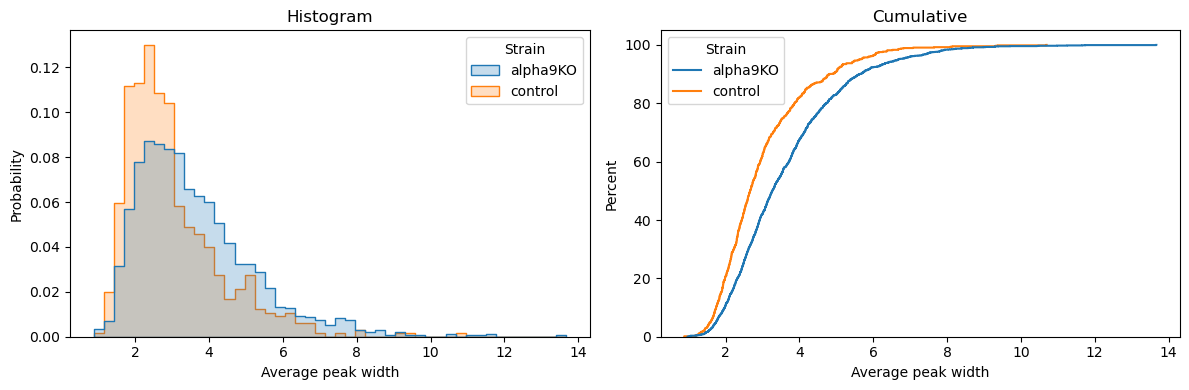

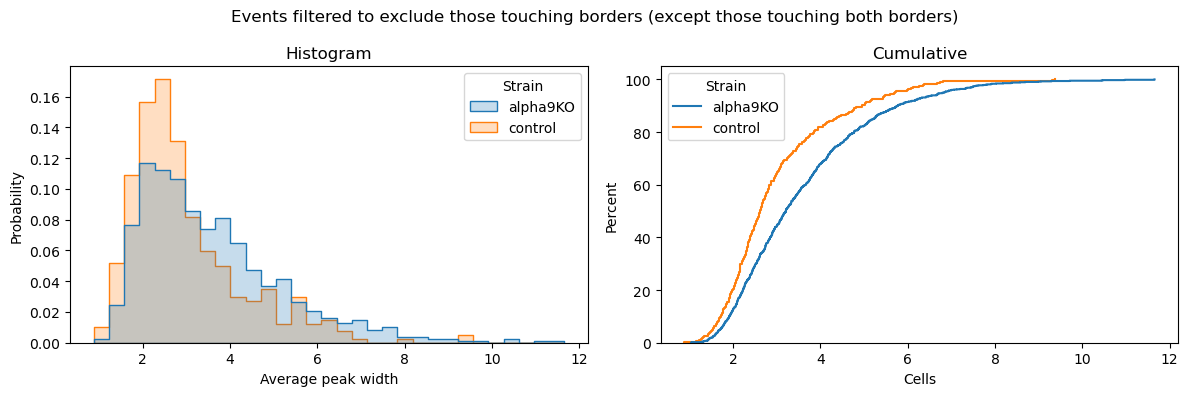

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(data=events_df[events_df['Age'].between(5, 10)], x='Average peak width', hue='Strain', element='step', stat='probability', common_norm=False, ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Average peak width')

# Right: cumulative
sns.ecdfplot(
    data=events_df[events_df['Age'].between(5, 10)],
    x='Average peak width',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)
axes[1].set_title('Cumulative')
axes[1].set_xlabel('Average peak width')

plt.tight_layout()
plt.show()



#Do not consider events that touch the borders, unless they touch both borders, in which case we keep them because they are likely to be true large events that just happen to have the origin near the border.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(data=events_df_only_contained[events_df_only_contained['Age'].between(5, 10)], x='Average peak width', hue='Strain', element='step', stat='probability', common_norm=False, ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Average peak width')

# Right: cumulative
sns.ecdfplot(
    data=events_df_only_contained[events_df_only_contained['Age'].between(5, 10)],
    x='Average peak width',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)

#sns.histplot(data=events_df_filtered, x='Cells', hue='Strain', element='step', stat='probability', common_norm=False,bins=np.arange(0.5, events_df_filtered['Cells'].max() + 1.5, 1), cumulative=True, ax=axes[1])
axes[1].set_title('Cumulative')
axes[1].set_xlabel('Cells')
plt.suptitle('Events filtered to exclude those touching borders (except those touching both borders)')
plt.tight_layout()
plt.show()



### Statistical test

Similarly to the other event-level properties, we use a linear mixed models with Mouse ID as the random factor.


In [59]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

anova_df = events_df[
    ["Average peak width", "Age", "Strain", "Mouse ID"]
].dropna().copy()

anova_df = anova_df.rename(columns={"Average peak width": "Fop"})

anova_df["Fop"] = pd.to_numeric(anova_df["Fop"], errors="coerce")
anova_df["Age"] = pd.to_numeric(anova_df["Age"], errors="coerce")

anova_df = anova_df.dropna(subset=["Fop", "Age", "Strain", "Mouse ID"])
anova_df = anova_df[anova_df["Age"] <= 15]

anova_df["Agegroup"] = pd.cut(
    anova_df["Age"],
    bins=[4, 10, 12, 15],
    labels=["5-10", "11-12", "13-15"]
)

#Define the reference strain : P5-10 Control
anova_df["Agegroup"] = pd.Categorical(
    anova_df["Agegroup"],
    categories=["5-10", "11-12", "13-15"],
    ordered=True
)

anova_df["Strain"] = pd.Categorical(
    anova_df["Strain"],
    categories=["control", "alpha9KO"],   # first one is reference
    ordered=True
)

anova_df["Age"] = pd.Categorical(
    anova_df["Age"],
    categories=sorted(anova_df["Age"].unique()),
    ordered=True
)

# model = smf.mixedlm(
#     "Fop ~ C(Agegroup) * C(Strain)",
#     data=anova_df,
#     groups=anova_df["Mouse ID"]
# ).fit()

# print(model.summary())

#anova_df = anova_df[anova_df["Age"]<=10]
age_order = ["5-10", "11-12", "13-15"]
#age_order = sorted(anova_df["Age"].unique())
p_values = []
for ref_age in age_order:
    new_order = [ref_age] + [a for a in age_order if a != ref_age]

    anova_df["Agegroup_ref"] = pd.Categorical(
        anova_df["Agegroup"],
        categories=new_order,
        ordered=True
    )

    model = smf.mixedlm(
        "Fop ~ C(Agegroup_ref) * C(Strain)",
        data=anova_df,
        groups=anova_df["Mouse ID"]
    ).fit()
    pvalue = float(model.summary().tables[1].loc["C(Strain)[T.alpha9KO]"]['P>|z|']) 
    p_values.append((ref_age, pvalue))
    print("\nReference age:", ref_age)
    print(model.summary().tables[1].loc["C(Strain)[T.alpha9KO]"])

adjusted_p_values = multipletests([p for _, p in p_values], method='holm')[1]
for (ref_age, pvalue), adj_p in zip(p_values, adjusted_p_values):
    print(f"Reference age: {ref_age}, original p-value: {pvalue:.4f}, adjusted p-value: {adj_p:.4f}")


Reference age: 5-10
Coef.       0.658
Std.Err.    0.222
z           2.968
P>|z|       0.003
[0.025      0.223
0.975]      1.092
Name: C(Strain)[T.alpha9KO], dtype: object

Reference age: 11-12
Coef.       1.549
Std.Err.    0.510
z           3.037
P>|z|       0.002
[0.025      0.549
0.975]      2.548
Name: C(Strain)[T.alpha9KO], dtype: object

Reference age: 13-15
Coef.        1.672
Std.Err.     1.740
z            0.961
P>|z|        0.337
[0.025      -1.739
0.975]       5.083
Name: C(Strain)[T.alpha9KO], dtype: object
Reference age: 5-10, original p-value: 0.0030, adjusted p-value: 0.0060
Reference age: 11-12, original p-value: 0.0020, adjusted p-value: 0.0060
Reference age: 13-15, original p-value: 0.3370, adjusted p-value: 0.3370


### Conclusions
Duration was significantly different at 5-10 and 11-12 (P = 0.006 for both ages.)

# Discard analysis from now on

In [96]:
# Build one row per event-peak (cell participating in an event)
peak_rows = []
for event_idx, event in events_df.reset_index(drop=True).iterrows():
    cell_ids = event['Cell IDs']
    peak_values = event['Peak values']
    peak_widths = event['Peak widths']
    peak_rise_times = event['Rise times']
    peak_decay_times = event['Decay times']

    for cell_id, peak_value, peak_width, peak_rise_time, peak_decay_time in zip(cell_ids, peak_values, peak_widths, peak_rise_times, peak_decay_times):
        peak_rows.append({
            'Event': event_idx,
            'Folder': event['Folder'],
            'Age': event['Age'],
            'Strain': event['Strain'],
            'Mouse ID': event['Mouse ID'],
            'Time (frame)': event['Time (frame)'],
            'Cell ID': cell_id,
            'Peak value': peak_value,
            'Peak width' : peak_width,
            'Peak rise time': peak_rise_time,
            'Peak decay time': peak_decay_time
        })

event_peaks_df = pd.DataFrame(peak_rows)

# Add centroid coordinates from allcells
cell_positions = (
    allcells[['Folder', 'Cell ID', 'Centroid x um', 'Centroid y um']]
    .drop_duplicates(subset=['Folder', 'Cell ID'])
)

event_peaks_df = event_peaks_df.merge(
    cell_positions,
    on=['Folder', 'Cell ID'],
    how='left'
)

# Parse ROI/cell number from Cell ID (digit after last underscore)
event_peaks_df['Cell number'] = pd.to_numeric(
    event_peaks_df['Cell ID'].str.rsplit('_', n=1).str[-1],
    errors='coerce'
)

# Single origin per event: row with highest peak value
origin_idx = event_peaks_df.groupby('Event')['Peak value'].idxmax()
origin_rows = event_peaks_df.loc[
    origin_idx,
    ['Event', 'Centroid x um', 'Centroid y um', 'Cell number']
].set_index('Event')

# Distance to origin in um
def distance_to_origin_um(row):
    if row['Event'] not in origin_rows.index:
        return np.nan

    ox = origin_rows.at[row['Event'], 'Centroid x um']
    oy = origin_rows.at[row['Event'], 'Centroid y um']
    if pd.isna(row['Centroid x um']) or pd.isna(row['Centroid y um']) or pd.isna(ox) or pd.isna(oy):
        return np.nan

    return float(np.linalg.norm(np.array([row['Centroid x um'], row['Centroid y um']]) - np.array([ox, oy])))

event_peaks_df['Distance to origin (um)'] = event_peaks_df.apply(distance_to_origin_um, axis=1)

# Distance to origin in cell numbers (signed)
event_peaks_df['Origin cell number'] = event_peaks_df['Event'].map(origin_rows['Cell number'])
event_peaks_df['Distance to origin (cell #)'] = event_peaks_df['Cell number'] - event_peaks_df['Origin cell number']

# Normalized peak values
event_max_per_event = event_peaks_df.groupby('Event')['Peak value'].transform('max')
event_peaks_df['Peak value (normalized event max)'] = event_peaks_df['Peak value'] / event_max_per_event
global_peak_max = event_peaks_df['Peak value'].max()
event_peaks_df['Peak value (normalized global max)'] = event_peaks_df['Peak value'] / global_peak_max

# Flag origin rows
event_peaks_df['Is origin'] = event_peaks_df['Distance to origin (cell #)'] == 0

# Bin distance values in um
distance_bin_size = 10
bins = np.arange(
    0,
    event_peaks_df['Distance to origin (um)'].max() + distance_bin_size,
    distance_bin_size
)

event_peaks_df['Distance bin'] = pd.cut(
    event_peaks_df['Distance to origin (um)'],
    bins=bins
).apply(lambda b: b.right if pd.notna(b) else np.nan)

event_peaks_df['Distance bin'] = event_peaks_df['Distance bin'].astype(float)
event_peaks_df.loc[event_peaks_df['Distance to origin (um)'] == 0, 'Distance bin'] = 0

# Filter: exclude events where the origin (max peak cell) is at leftmost or rightmost position
# For each event, determine min and max cell numbers
event_cell_ranges = event_peaks_df.groupby('Event')['Cell number'].agg(['min', 'max'])
event_peaks_df = event_peaks_df.merge(
    event_cell_ranges.reset_index().rename(columns={'min': 'Event min cell', 'max': 'Event max cell'}),
    on='Event',
    how='left'
)

# Filter: keep only events where origin is strictly between min and max
valid_events = event_peaks_df[
    (event_peaks_df['Origin cell number'] > event_peaks_df['Event min cell']) &
    (event_peaks_df['Origin cell number'] < event_peaks_df['Event max cell'])
]['Event'].unique()

print(f"Total events: {event_peaks_df['Event'].nunique()}, Valid events after filtering: {len(valid_events)}")
event_peaks_df = event_peaks_df[event_peaks_df['Event'].isin(valid_events)].copy()
# Drop temporary columns
event_peaks_df = event_peaks_df.drop(columns=['Event min cell', 'Event max cell'])

event_peaks_df

Total events: 2235, Valid events after filtering: 1811


,Event,Folder,Age,Strain,Mouse ID,Time (frame),Cell ID,Peak value,Peak width,Peak rise time,...,Centroid x um,Centroid y um,Cell number,Distance to origin (um),Origin cell number,Distance to origin (cell #),Peak value (normalized event max),Peak value (normalized global max),Is origin,Distance bin
0,0,Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-M...,7,alpha9KO,3,1731.000000,2025.08.05_alpha9KO_3_11_001_ROI_4,0.693559,3.092749,0.718165,...,32.659787,33.586958,4,25.572384,7,-3,0.315608,0.049683,False,30.0
1,0,Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-M...,7,alpha9KO,3,1731.000000,2025.08.05_alpha9KO_3_11_001_ROI_5,0.645450,2.925090,1.615871,...,27.257720,39.413217,5,18.683634,7,-2,0.293715,0.046236,False,20.0
2,0,Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-M...,7,alpha9KO,3,1731.000000,2025.08.05_alpha9KO_3_11_001_ROI_7,2.197538,2.436614,1.436330,...,24.868112,57.943407,7,0.000000,7,0,1.000000,0.157419,True,0.0
3,0,Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-M...,7,alpha9KO,3,1731.000000,2025.08.05_alpha9KO_3_11_001_ROI_8,1.582103,2.359240,1.436330,...,21.843747,74.265990,8,16.600407,7,1,0.719943,0.113333,False,20.0
4,1,Z:/Users/Francesca/Data/2025/2025_08_05_a9KO-M...,7,alpha9KO,3,1918.200000,2025.08.05_alpha9KO_3_11_002_ROI_6,0.413014,1.743593,0.628394,...,28.492765,57.034541,6,47.400139,12,-6,0.515036,0.029586,False,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19170,2233,Z:/Users/Rinta/Data/2026/In vivo/5-03-2026 P5 ...,5,alpha9KO,90,15499.647059,2026.03.02_alpha9KO_90_2_ROI_19,1.016962,5.177438,3.725481,...,51.458227,159.706590,19,70.263824,11,8,0.293128,0.072849,False,80.0
19171,2234,Z:/Users/Rinta/Data/2026/In vivo/5-03-2026 P5 ...,5,alpha9KO,90,16709.000000,2026.03.02_alpha9KO_90_2_ROI_1,1.421229,2.912440,0.897706,...,35.103279,2.534307,1,35.244808,5,-4,0.536505,0.101809,False,40.0
19172,2234,Z:/Users/Rinta/Data/2026/In vivo/5-03-2026 P5 ...,5,alpha9KO,90,16709.000000,2026.03.02_alpha9KO_90_2_ROI_2,1.291049,2.012197,0.763050,...,38.147387,9.767748,2,27.562576,5,-3,0.487363,0.092483,False,30.0
19173,2234,Z:/Users/Rinta/Data/2026/In vivo/5-03-2026 P5 ...,5,alpha9KO,90,16709.000000,2026.03.02_alpha9KO_90_2_ROI_5,2.649049,2.673756,1.211904,...,42.680057,36.955071,5,0.000000,5,0,1.000000,0.189762,True,0.0


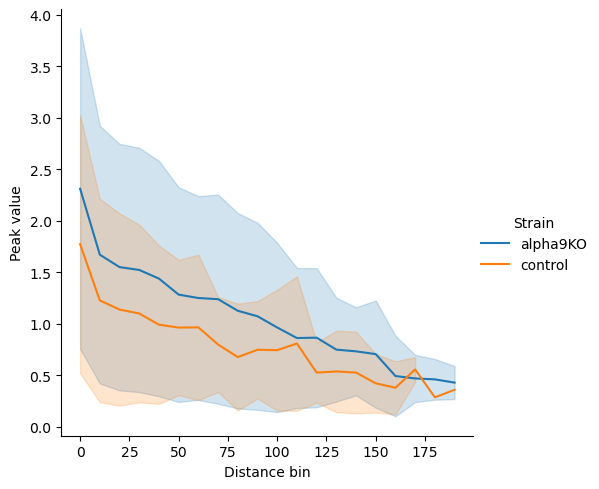

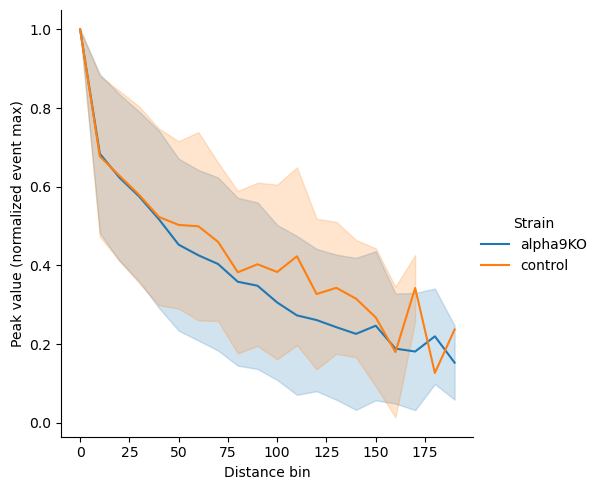

In [97]:
sns.relplot(data=event_peaks_df[(event_peaks_df['Age']>=5) & (event_peaks_df['Age']<=10)], x='Distance bin', y='Peak value', hue='Strain', kind='line', estimator='mean', errorbar='sd')

sns.relplot(data=event_peaks_df[(event_peaks_df['Age']>=5) & (event_peaks_df['Age']<=10)], x='Distance bin', y='Peak value (normalized event max)', hue='Strain', kind='line', estimator='mean', errorbar='sd')

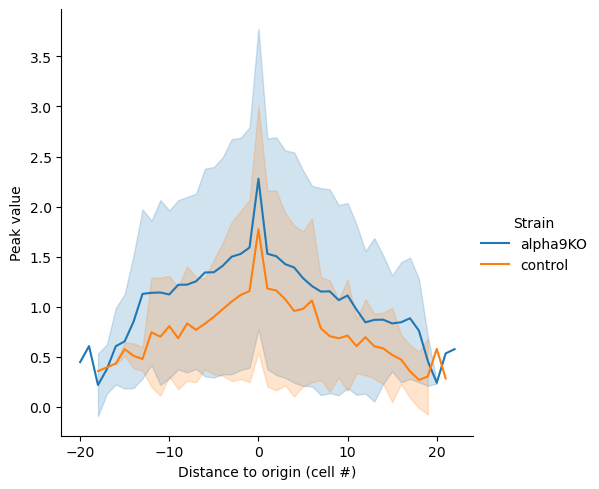

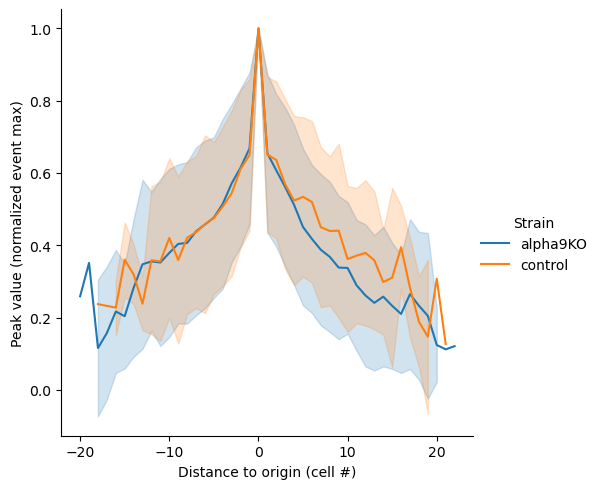

In [98]:
sns.relplot(data=event_peaks_df, x='Distance to origin (cell #)', y='Peak value', hue='Strain', kind='line', estimator='mean', errorbar='sd')
sns.relplot(data=event_peaks_df, x='Distance to origin (cell #)', y='Peak value (normalized event max)', hue='Strain', kind='line', estimator='mean', errorbar='sd')

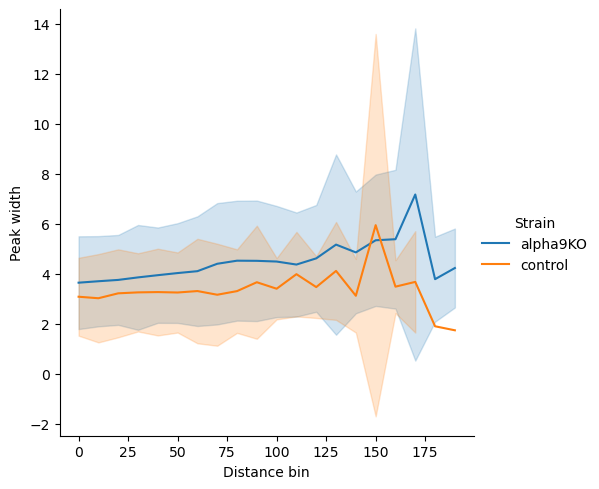

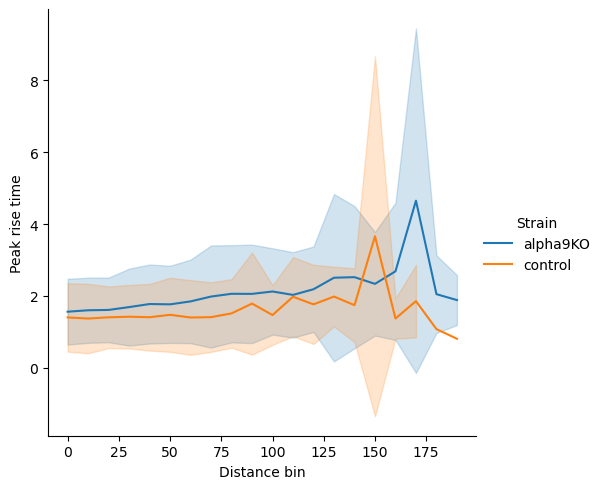

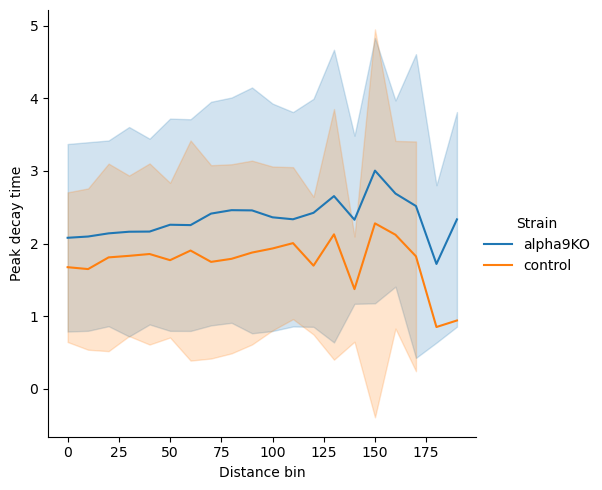

In [99]:
sns.relplot(data=event_peaks_df[(event_peaks_df['Age']>=5) & (event_peaks_df['Age']<=10)], x='Distance bin', y='Peak width', hue='Strain', kind='line', estimator='mean', errorbar='sd')

sns.relplot(data=event_peaks_df[(event_peaks_df['Age']>=5) & (event_peaks_df['Age']<=10)], x='Distance bin', y='Peak rise time', hue='Strain', kind='line', estimator='mean', errorbar='sd')

sns.relplot(data=event_peaks_df[(event_peaks_df['Age']>=5) & (event_peaks_df['Age']<=10)], x='Distance bin', y='Peak decay time', hue='Strain', kind='line', estimator='mean', errorbar='sd')


In [100]:
events_df['Reached left border'].value_counts()

#events_df['Reached right border'].value_counts()

#len(events_df)

Reached left border
False    1477
True      758
Name: count, dtype: int64

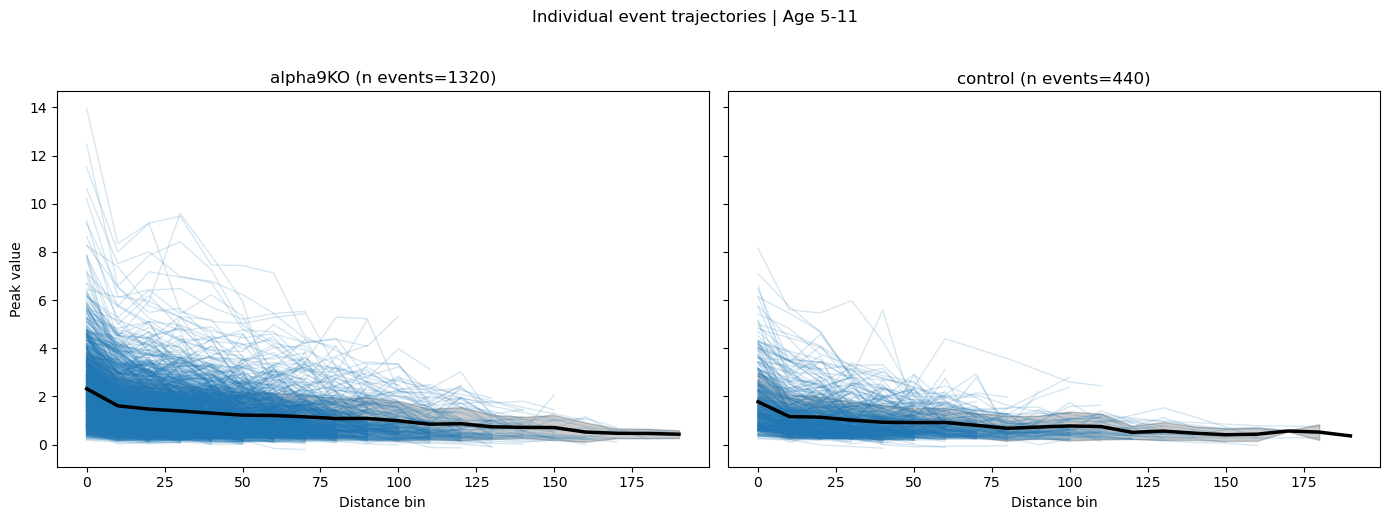

In [102]:
# Plot trajectories of individual events (one line per event)
age_min, age_max = 5, 11
y_col = 'Peak value'
max_events_per_strain = 80000
random_state = 42

plot_df = event_peaks_df[
    (event_peaks_df['Age'] >= age_min) &
    (event_peaks_df['Age'] <= age_max)
].copy()

# If multiple rows exist at same Event/distance, average them first
plot_df = (
    plot_df.groupby(['Event', 'Strain', 'Distance bin'], as_index=False)[y_col]
    .mean()
)

# Keep a manageable number of events per strain for readability
selected_parts = []
for strain_name, strain_df in plot_df.groupby('Strain'):
    event_ids = strain_df['Event'].drop_duplicates()
    if len(event_ids) > max_events_per_strain:
        event_ids = event_ids.sample(max_events_per_strain, random_state=random_state)
    selected_parts.append(strain_df[strain_df['Event'].isin(event_ids)])

plot_df = pd.concat(selected_parts, ignore_index=True)

strains = sorted(plot_df['Strain'].unique())
fig, axes = plt.subplots(1, len(strains), figsize=(7 * len(strains), 5), sharey=True)
if len(strains) == 1:
    axes = [axes]

for ax, strain_name in zip(axes, strains):
    strain_df = plot_df[plot_df['Strain'] == strain_name]

    # Individual event trajectories
    sns.lineplot(
        data=strain_df,
        x='Distance bin',
        y=y_col,
        units='Event',
        estimator=None,
        lw=1,
        alpha=0.18,
        color='tab:blue',
        legend=False,
        ax=ax,
    )

    # Mean trajectory overlay
    sns.lineplot(
        data=strain_df,
        x='Distance bin',
        y=y_col,
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        color='black',
        ax=ax,
    )

    ax.set_title(f"{strain_name} (n events={strain_df['Event'].nunique()})")
    ax.set_xlabel('Distance bin')
    ax.set_ylabel(y_col)

plt.suptitle(f'Individual event trajectories | Age {age_min}-{age_max}', y=1.03)
plt.tight_layout()
plt.show()

<Axes: xlabel='Peak value', ylabel='Percent'>

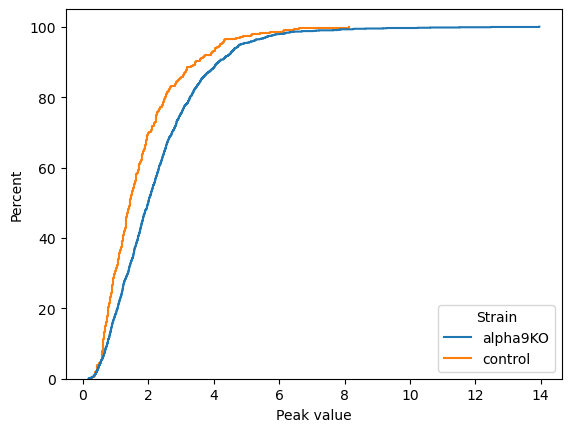

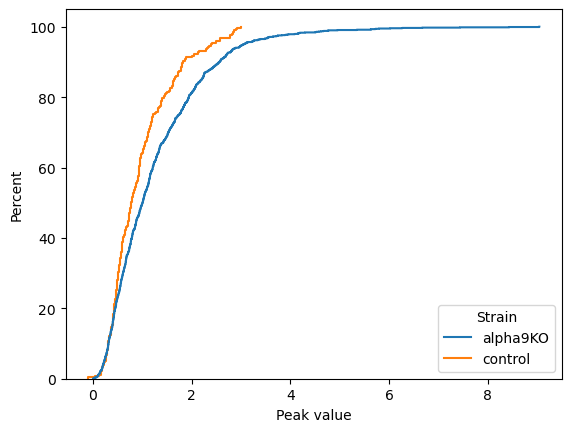

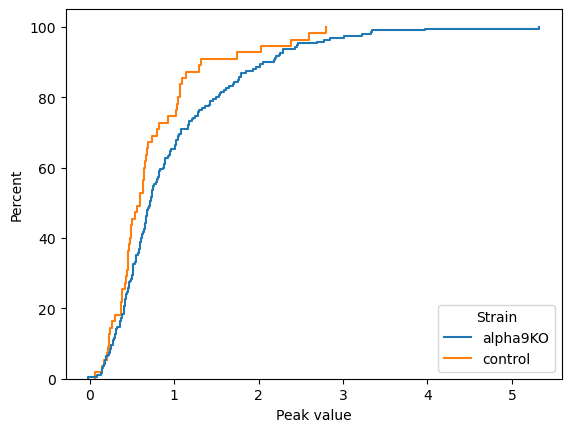

In [103]:
sns.ecdfplot(data = event_peaks_df[event_peaks_df['Distance bin'] == 0], hue = 'Strain', x = 'Peak value',  stat='percent')

plt.figure()
sns.ecdfplot(data = event_peaks_df[event_peaks_df['Distance bin'] == 50], hue = 'Strain', x = 'Peak value',  stat='percent')

plt.figure()
sns.ecdfplot(data = event_peaks_df[event_peaks_df['Distance bin'] == 100], hue = 'Strain', x = 'Peak value',  stat='percent')


<Axes: xlabel='Peak width', ylabel='Percent'>

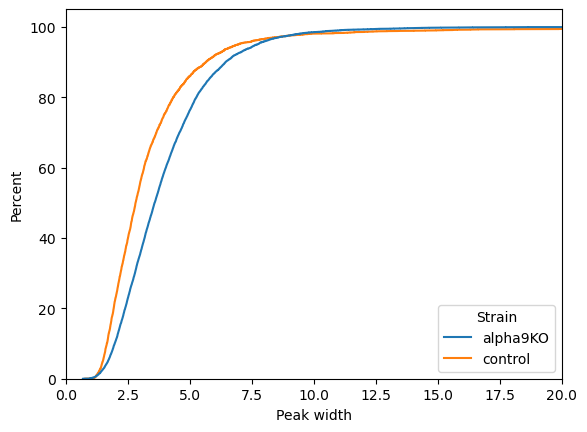

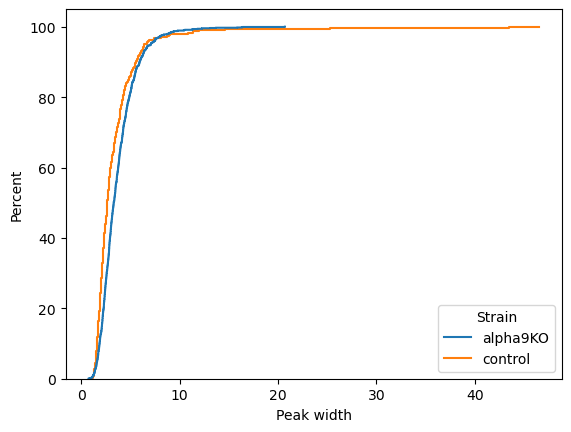

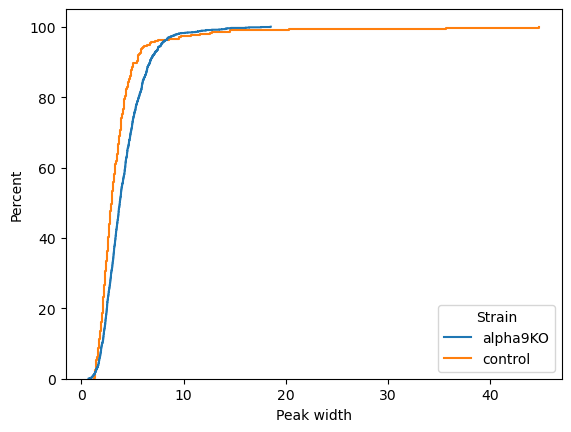

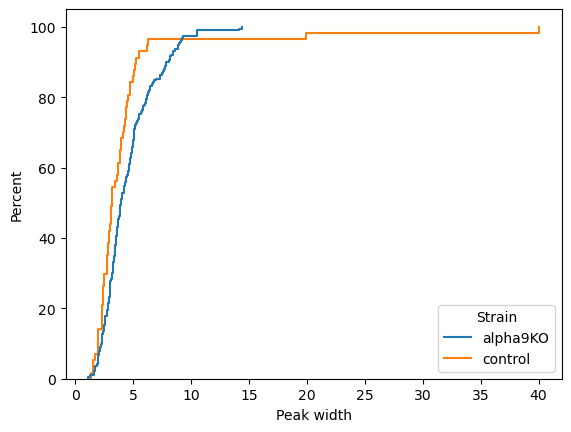

In [235]:
sns.ecdfplot(data = event_peaks_df, hue = 'Strain', x = 'Peak width',  stat='percent')
plt.xlim(0, 20)

plt.figure()

sns.ecdfplot(data = event_peaks_df[event_peaks_df['Distance bin'] == 0], hue = 'Strain', x = 'Peak width',  stat='percent')

plt.figure()
sns.ecdfplot(data = event_peaks_df[event_peaks_df['Distance bin'] == 50], hue = 'Strain', x = 'Peak width',  stat='percent')

plt.figure()
sns.ecdfplot(data = event_peaks_df[event_peaks_df['Distance bin'] == 100], hue = 'Strain', x = 'Peak width',  stat='percent')


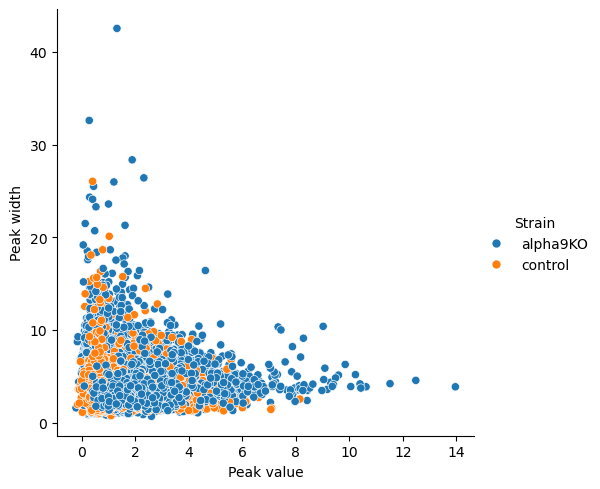

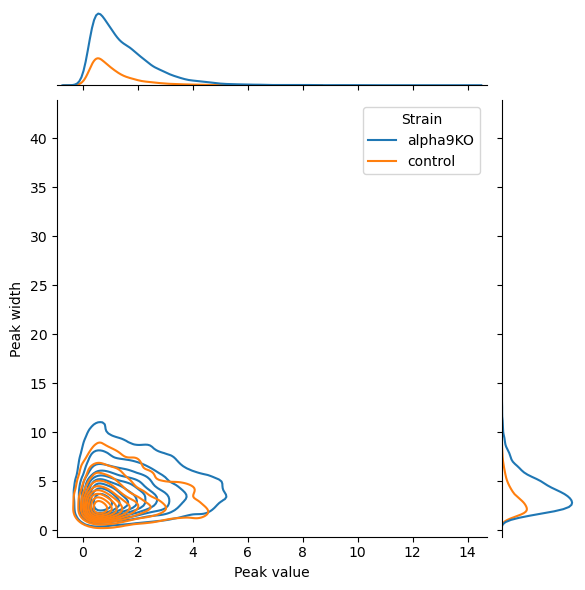

In [104]:
sns.relplot(data= event_peaks_df, x='Peak value', y='Peak width', hue='Strain', kind='scatter')
sns.jointplot(data= event_peaks_df, x='Peak value', y='Peak width', hue='Strain', kind='kde',common_norm=False)

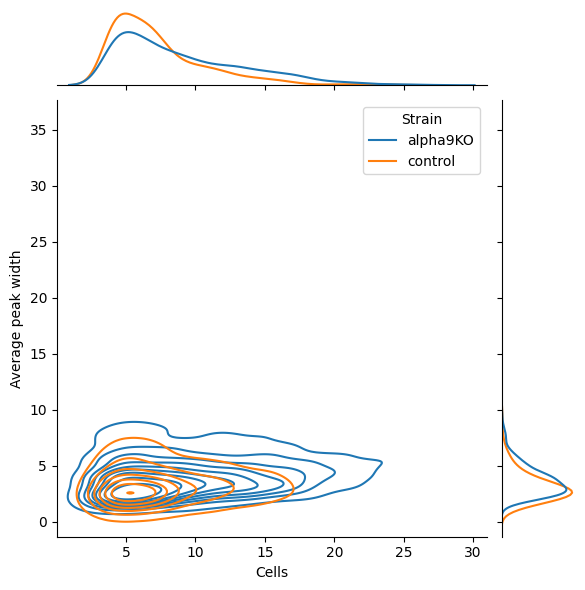

In [ ]:

sns.jointplot(data=events_df, x='Cells', y='Average peak width', hue='Strain',kind='kde',marginal_kws=dict(common_norm=False))

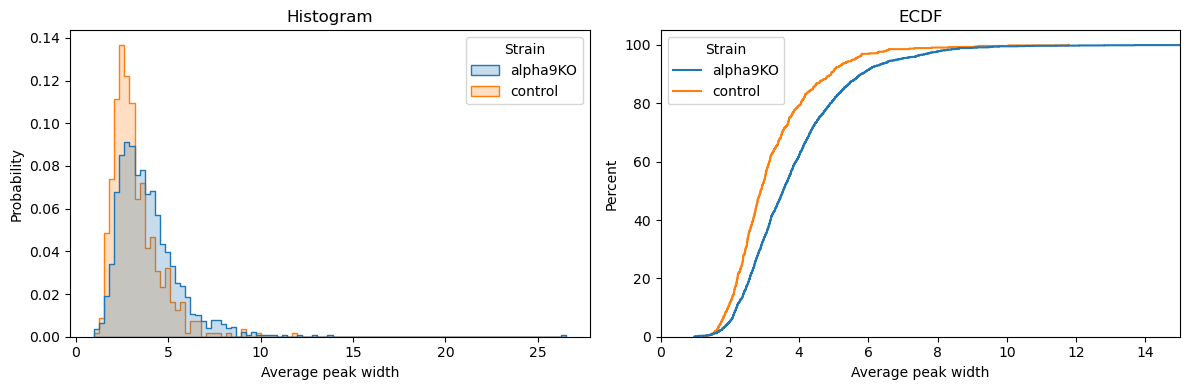

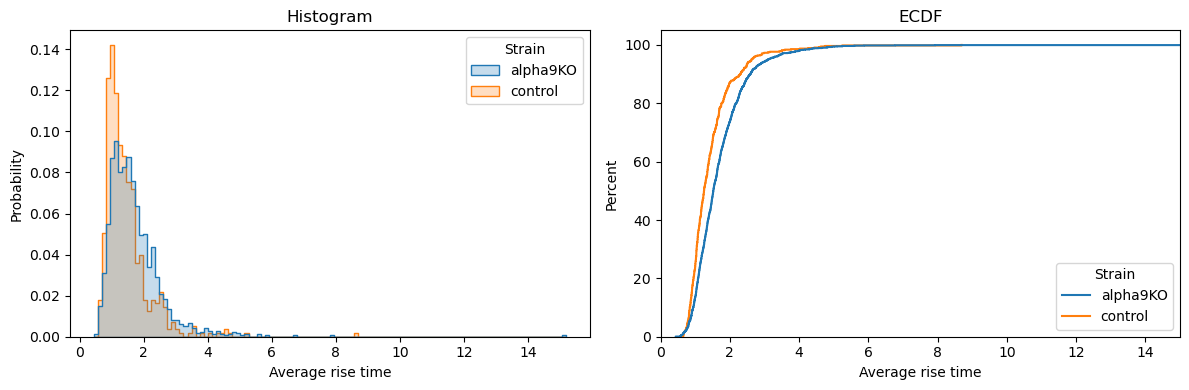

(0.0, 15.0)

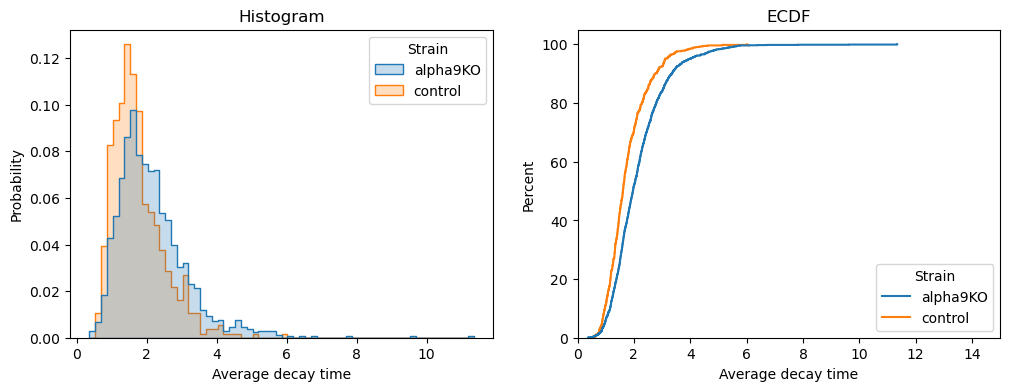

In [105]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(
    data=events_df,
    x='Average peak width',
    hue='Strain',
    element='step',
    stat='probability',
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Average peak width')

# Right: ECDF
sns.ecdfplot(
    data=events_df,
    x='Average peak width',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)
axes[1].set_title('ECDF')
axes[1].set_xlabel('Average peak width')
axes[1].set_xlim(0, 15)

plt.tight_layout()
plt.show()


####################################
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(
    data=events_df,
    x='Average rise time',
    hue='Strain',
    element='step',
    stat='probability',
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Average rise time')

# Right: ECDF
sns.ecdfplot(
    data=events_df,
    x='Average rise time',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)
axes[1].set_title('ECDF')
axes[1].set_xlabel('Average rise time')
axes[1].set_xlim(0, 15)

plt.tight_layout()
plt.show()



####################################
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram
sns.histplot(
    data=events_df,
    x='Average decay time',
    hue='Strain',
    element='step',
    stat='probability',
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Average decay time')

# Right: ECDF
sns.ecdfplot(
    data=events_df,
    x='Average decay time',
    hue='Strain',
    stat='percent',
    ax=axes[1]
)
axes[1].set_title('ECDF')
axes[1].set_xlabel('Average decay time')
axes[1].set_xlim(0, 15)


In [51]:
from scipy.stats import mannwhitneyu
events_df2 = events_df[(events_df['Age']>=5) & (events_df['Age']<=10)]


a = events_df.loc[(events_df['Strain']=='control'),'Average decay time']
b = events_df.loc[(events_df['Strain']=='alpha9KO'),'Average decay time']
print('Average decay time',mannwhitneyu(a,b))

a = events_df.loc[(events_df['Strain']=='control'),'Average rise time']
b = events_df.loc[(events_df['Strain']=='alpha9KO'),'Average rise time']
print('Average rise time',mannwhitneyu(a,b))

a = events_df.loc[(events_df['Strain']=='control'),'Average peak width']
b = events_df.loc[(events_df['Strain']=='alpha9KO'),'Average peak width']
print('Average peak width time',mannwhitneyu(a,b))

Average decay time MannwhitneyuResult(statistic=428952.0, pvalue=1.011378751716705e-14)
Average rise time MannwhitneyuResult(statistic=439485.0, pvalue=2.2439749765409594e-12)
Average peak width time MannwhitneyuResult(statistic=425564.0, pvalue=1.5968731258003872e-15)


Average decay time MannwhitneyuResult(statistic=175.0, pvalue=0.0028132221642463437)
Average rise time MannwhitneyuResult(statistic=194.0, pvalue=0.008181817023467387)
Average peak width time MannwhitneyuResult(statistic=185.0, pvalue=0.005001574083162136)


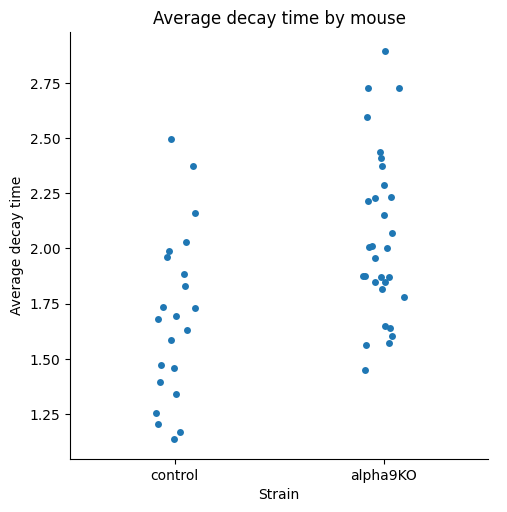

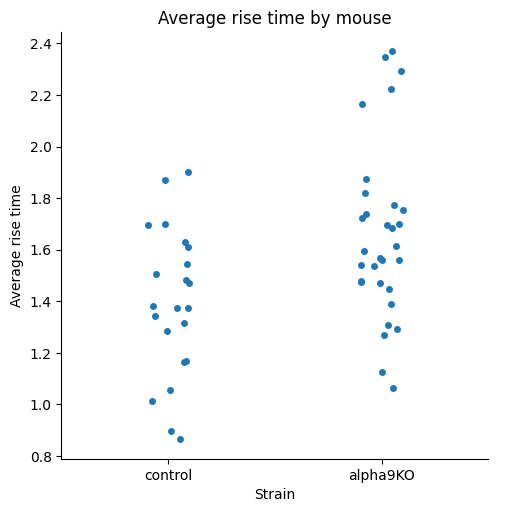

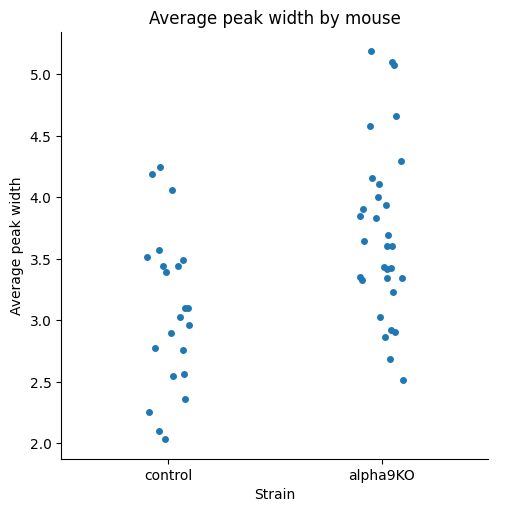

In [52]:
events_df_by_mouse = events_df.groupby('Mouse ID')[['Average peak width','Average rise time','Average decay time','Strain','Age']].agg({
    'Average peak width':'mean',
    'Average rise time':'mean',
    'Average decay time':'mean',
    'Strain':'first',
    'Age':'first'
})


events_df2 = events_df_by_mouse[(events_df_by_mouse['Age']>=5) & (events_df_by_mouse['Age']<=10)]
events_df2 = events_df2[events_df2['Average rise time']<6]

a = events_df2.loc[(events_df2['Strain']=='control'),'Average decay time']
b = events_df2.loc[(events_df2['Strain']=='alpha9KO'),'Average decay time']
sns.catplot(data=events_df2,x='Strain',y='Average decay time',kind='strip',order = ['control','alpha9KO'])
plt.title('Average decay time by mouse')
print('Average decay time',mannwhitneyu(a,b))

a = events_df2.loc[(events_df2['Strain']=='control'),'Average rise time']
b = events_df2.loc[(events_df2['Strain']=='alpha9KO'),'Average rise time']
sns.catplot(data=events_df2,x='Strain',y='Average rise time',kind='strip',order = ['control','alpha9KO'])
plt.title('Average rise time by mouse')
print('Average rise time',mannwhitneyu(a,b))

a = events_df2.loc[(events_df2['Strain']=='control'),'Average peak width']
b = events_df2.loc[(events_df2['Strain']=='alpha9KO'),'Average peak width']
sns.catplot(data=events_df2,x='Strain',y='Average peak width',kind='strip',order = ['control','alpha9KO'])
plt.title('Average peak width by mouse')
print('Average peak width time',mannwhitneyu(a,b))

# Data export #TODO

In [53]:
# Export all dataframes needed for publication figures

import os

# Create export directory if it doesn't exist
export_dir = Path('../../analysis_results/publication_data')
export_dir.mkdir(parents=True, exist_ok=True)

print("Exporting dataframes for publication figures...")

# 1. Cell-level data (for histograms)
allcells_combined.to_parquet(export_dir / 'allcells_combined.parquet')
print(f"✓ Exported allcells_combined: {len(allcells_combined)} rows")

# 2. Recording-level data
allcells_combined_by_recording.to_parquet(export_dir / 'allcells_combined_by_recording.parquet')
print(f"✓ Exported allcells_combined_by_recording: {len(allcells_combined_by_recording)} rows")

# 3. Mouse-level data (for statistics)
allcells_by_mouse.to_parquet(export_dir / 'allcells_by_mouse.parquet')
print(f"✓ Exported allcells_by_mouse: {len(allcells_by_mouse)} rows")

# 4. Events dataframe (event-level information)
events_df.to_parquet(export_dir / 'events_df.parquet')
print(f"✓ Exported events_df: {len(events_df)} rows")

# 5. Event traces (time series for each event)
events_traces_df.to_parquet(export_dir / 'events_traces_df.parquet')
print(f"✓ Exported events_traces_df: {len(events_traces_df)} rows")

# 6. Event peaks (spatial propagation analysis)
event_peaks_df.to_parquet(export_dir / 'event_peaks_df.parquet')
print(f"✓ Exported event_peaks_df: {len(event_peaks_df)} rows")

# 7. Mouse-level event kinetics (for statistics)
events_df_by_mouse.to_parquet(export_dir / 'events_df_by_mouse.parquet')
print(f"✓ Exported events_df_by_mouse: {len(events_df_by_mouse)} rows")

# 8. Correlation analysis results
results_df['Distance_bin'] = results_df['Distance_bin'].astype(str)
results_df.to_parquet(export_dir / 'correlation_results_df.parquet')
print(f"✓ Exported correlation_results_df: {len(results_df)} rows")

results_df_avg.to_parquet(export_dir / 'correlation_results_df_avg.parquet')
print(f"✓ Exported correlation_results_df_avg: {len(results_df_avg)} rows")

# 9. Export metadata/parameters as JSON
import json
metadata = {
    'age_filter': {'min': 5, 'max': 10},
    'event_detection_params': {
        'MAX_PEAK_DISTANCE': MAX_PEAK_DISTANCE,
        'MIN_CELLS': MIN_CELLS,
        'MAX_CELL_SKIP': MAX_CELL_SKIP,
        'TRACE_WINDOW_SECONDS': TRACE_WINDOW_SECONDS,
        'BASELINE_WINDOW': BASELINE_WINDOW,
        'COMMON_SAMPLING_RATE': COMMON_SAMPLING_RATE
    },
    'n_samples': {
        'total_mice': len(allcells_by_mouse),
        'control_mice': len(allcells_by_mouse[allcells_by_mouse['Strain']=='control']),
        'alpha9KO_mice': len(allcells_by_mouse[allcells_by_mouse['Strain']=='alpha9KO']),
        'total_cells': len(allcells_combined),
        'total_events': len(events_df),
        'total_recordings': len(allcells_combined_by_recording)
    }
}

with open(export_dir / 'analysis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Exported analysis_metadata.json")

print(f"\n{'='*60}")
print(f"All dataframes exported to: {export_dir}")
print(f"{'='*60}")
print("\nSummary of exported files:")
print(f"  • Cell-level: allcells_combined.parquet")
print(f"  • Recording-level: allcells_combined_by_recording.parquet")
print(f"  • Mouse-level: allcells_by_mouse.parquet")
print(f"  • Events: events_df.parquet")
print(f"  • Event traces: events_traces_df.parquet")
print(f"  • Event spatial data: event_peaks_df.parquet")
print(f"  • Mouse event kinetics: events_df_by_mouse.parquet")
print(f"  • Correlation results: correlation_results_df.parquet")
print(f"  • Correlation averaged: correlation_results_df_avg.parquet")
print(f"  • Metadata: analysis_metadata.json")
print(f"\nReady for publication figure generation!")

Exporting dataframes for publication figures...
✓ Exported allcells_combined: 3135 rows
✓ Exported allcells_combined_by_recording: 174 rows
✓ Exported allcells_by_mouse: 70 rows
✓ Exported events_df: 2371 rows
✓ Exported events_traces_df: 10067334 rows
✓ Exported event_peaks_df: 17417 rows
✓ Exported events_df_by_mouse: 68 rows
✓ Exported correlation_results_df: 23692 rows
✓ Exported correlation_results_df_avg: 1274 rows
✓ Exported analysis_metadata.json

All dataframes exported to: ..\..\analysis_results\publication_data

Summary of exported files:
  • Cell-level: allcells_combined.parquet
  • Recording-level: allcells_combined_by_recording.parquet
  • Mouse-level: allcells_by_mouse.parquet
  • Events: events_df.parquet
  • Event traces: events_traces_df.parquet
  • Event spatial data: event_peaks_df.parquet
  • Mouse event kinetics: events_df_by_mouse.parquet
  • Correlation results: correlation_results_df.parquet
  • Correlation averaged: correlation_results_df_avg.parquet
  • Metad

# Plots

#

In [137]:
def plot_folder_traces_with_event_peaks(
    folder_name,
    events_df,
    cells,
    traces_table=None,
    use_zscore=True,
    peak_search_radius=10,
):
    if traces_table is None:
        traces_table = alltraces

    folder_cells = cells[cells['Folder'] == folder_name].copy()
    if folder_cells.empty:
        raise ValueError(f"Folder not found in cells dataframe: {folder_name}")

    folder_events = events_df[events_df['Folder'] == folder_name].copy().reset_index(drop=False)
    if folder_events.empty:
        print('No events found for this folder in events_df. Plotting traces and all peaks only.')

    fps = float(folder_cells['fps'].iloc[0])
    cell_ids = folder_cells['Cell ID'].tolist()

    traces_raw = traces_table[cell_ids].copy()
    traces_plot = traces_raw.copy()
    if use_zscore:
        traces_plot = (traces_plot - traces_plot.mean()) / traces_plot.std()

    cell_order = pd.Series(cell_ids).sort_values(
        key=lambda s: pd.to_numeric(s.str.rsplit('_', n=1).str[-1], errors='coerce')
    ).tolist()
    traces_plot = traces_plot[cell_order]

    values = traces_plot.to_numpy(dtype=float)
    span = np.nanpercentile(values, 99) - np.nanpercentile(values, 1)
    offset_step = span * 1.2 if span > 0 else 4.0
    offsets = np.arange(len(cell_order)) * offset_step
    cell_to_row = {cell_id: i for i, cell_id in enumerate(cell_order)}

    fig, ax = plt.subplots(figsize=(16, max(6, 0.35 * len(cell_order))))
    time_axis = traces_plot.index.to_numpy(dtype=float) / fps

    # Plot all traces
    for i, cell_id in enumerate(cell_order):
        y = traces_plot[cell_id].to_numpy(dtype=float) + offsets[i]
        ax.plot(time_axis, y, color='0.25', linewidth=0.8)

    # Plot all detected peaks from cells (small gray points)
    for _, row in folder_cells.iterrows():
        cell_id = row['Cell ID']
        row_idx = cell_to_row.get(cell_id)
        if row_idx is None:
            continue
        for peak_frame in row['Peak positions']:
            peak_frame = int(peak_frame)
            if peak_frame < 0 or peak_frame >= len(traces_plot):
                continue
            y_point = traces_plot.loc[peak_frame, cell_id] + offsets[row_idx]
            ax.scatter(
                peak_frame / fps,
                y_point,
                s=10,
                color='0.75',
                edgecolor='none',
                zorder=2,
            )

    # Highlight event peaks from events_df (colored by event number)
    n_events = int(len(folder_events))
    cmap = plt.cm.get_cmap('turbo', max(n_events, 2))

    for event_num, (_, event_row) in enumerate(folder_events.iterrows()):
        event_color = cmap(event_num)
        event_frame = int(round(event_row['Time (frame)']))
        event_cells = event_row['Cell IDs'] if isinstance(event_row['Cell IDs'], list) else []
        
        # Get the peak margins (lists corresponding to each cell in the event)
        peak_left_margins = event_row.get('Peak left margin', [])
        peak_right_margins = event_row.get('Peak right margin', [])

        for cell_idx, cell_id in enumerate(event_cells):
            row_idx = cell_to_row.get(cell_id)
            if row_idx is None:
                continue

            # Refine displayed peak near event frame for that cell (visual-only)
            left = max(0, event_frame - peak_search_radius)
            right = min(len(traces_plot) - 1, event_frame + peak_search_radius)
            local_window = traces_plot.iloc[left:right + 1][cell_id]
            if local_window.empty:
                continue

            refined_frame = int(local_window.idxmax())
            y_point = float(local_window.max()) + offsets[row_idx]

            # Plot peak maximum
            ax.scatter(
                refined_frame / fps,
                y_point,
                s=40,
                color=event_color,
                edgecolor='k',
                linewidth=0.35,
                zorder=4,
            )
            
            # Plot left and right margins (50% peak height) if available
            if cell_idx < len(peak_left_margins) and cell_idx < len(peak_right_margins):
                left_margin = peak_left_margins[cell_idx]
                right_margin = peak_right_margins[cell_idx]
                
                if not np.isnan(left_margin) and 0 <= int(left_margin) < len(traces_plot):
                    left_frame = int(left_margin)
                    y_left = traces_plot.loc[left_frame, cell_id] + offsets[row_idx]
                    ax.scatter(
                        left_margin / fps,
                        y_left,
                        s=40,
                        marker='+',
                        color=event_color,
                        linewidths=1.5,
                        zorder=4,
                    )
                
                if not np.isnan(right_margin) and 0 <= int(right_margin) < len(traces_plot):
                    right_frame = int(right_margin)
                    y_right = traces_plot.loc[right_frame, cell_id] + offsets[row_idx]
                    ax.scatter(
                        right_margin / fps,
                        y_right,
                        s=40,
                        marker='+',
                        color=event_color,
                        linewidths=1.5,
                        zorder=4,
                    )

    ax.set_yticks(offsets)
    ax.set_yticklabels([c.rsplit('_', 1)[-1] for c in cell_order])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cell number (stacked)')
    ax.set_title(f"{folder_name} | Events in events_df: {n_events} | Cells: {len(cell_order)}")

    if n_events > 0:
        norm = plt.Normalize(vmin=0, vmax=max(n_events - 1, 1))
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('Event number (row in folder subset)')

    plt.tight_layout()
    plt.show()

    return folder_events


# Example usage:
# folder_name = cells['Folder'].iloc[0]
# folder_events = plot_folder_traces_with_event_peaks(folder_name, events_df=events_df, cells=allcells)

/var/folders/n2/bkzw0ff907zgpgprdz_rg_tr0000gn/T/ipykernel_98580/110188558.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('turbo', max(n_events, 2))


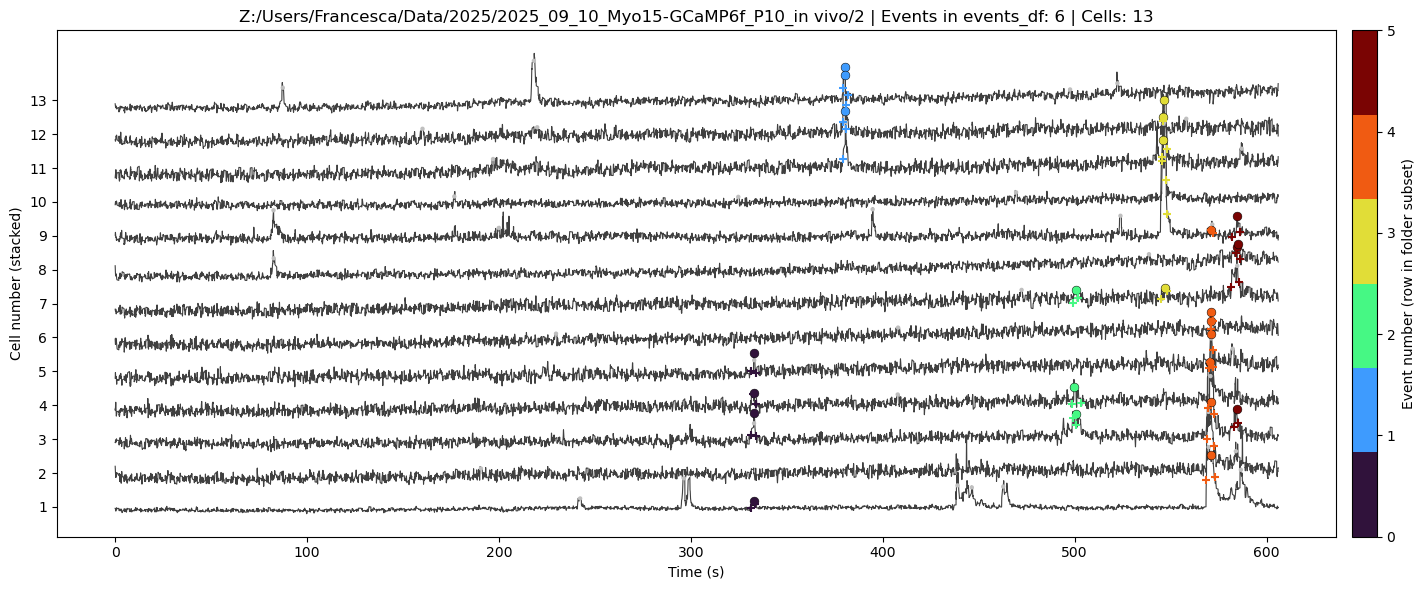

Folder: Z:/Users/Francesca/Data/2025/2025_09_10_Myo15-GCaMP6f_P10_in vivo/2
Events in this folder: 6


/var/folders/n2/bkzw0ff907zgpgprdz_rg_tr0000gn/T/ipykernel_98580/110188558.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('turbo', max(n_events, 2))


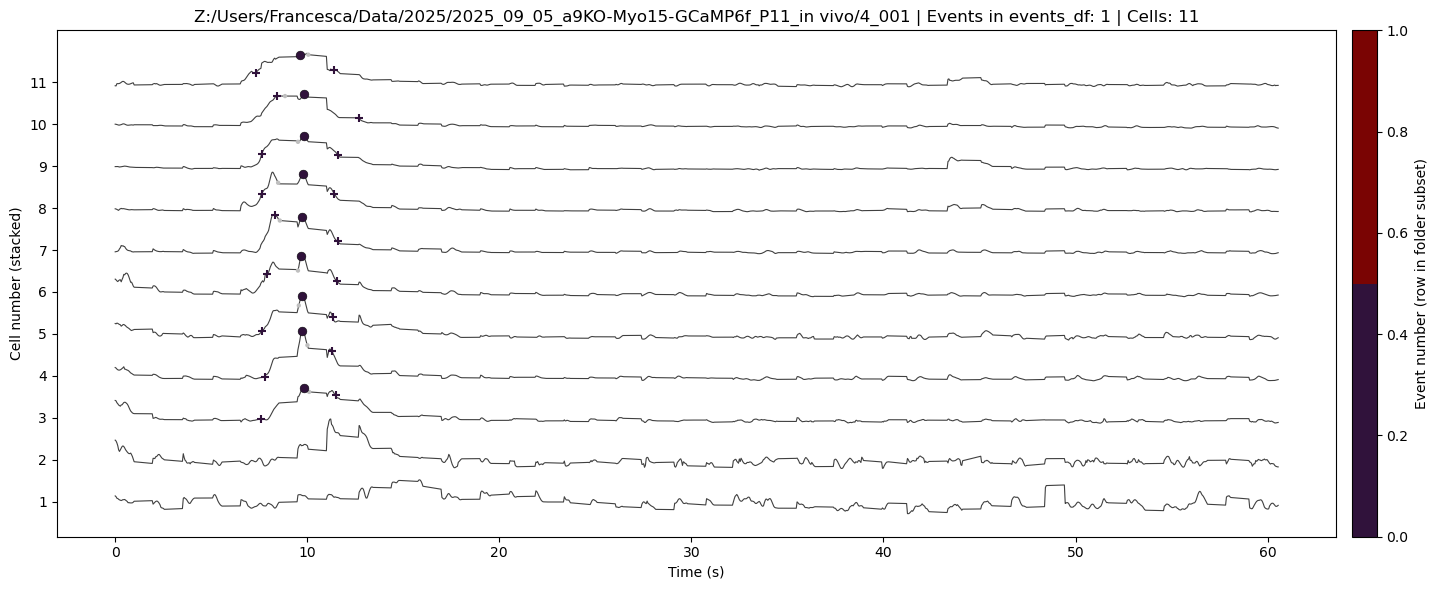

Folder: Z:/Users/Francesca/Data/2025/2025_09_05_a9KO-Myo15-GCaMP6f_P11_in vivo/4_001
Events in this folder: 1


In [203]:
# choose three random control and three random mutant experiments
control_exp = events_df[events_df['Strain']=='control']['Folder'].unique()
mutant_exp = events_df[events_df['Strain']=='alpha9KO']['Folder'].unique()
np.random.seed(100)
chosen_control = np.random.choice(control_exp, 1, replace=False)
chosen_mutant = np.random.choice(mutant_exp, 1, replace=False)


for sample_folder in list(chosen_control) + list(chosen_mutant):
    folder_events = plot_folder_traces_with_event_peaks(
        folder_name=sample_folder,
        events_df=events_df,
        cells=allcells,
        traces_table=alltraces,
        use_zscore=True,
        peak_search_radius=10,
    )

    print(f"Folder: {sample_folder}")
    print(f"Events in this folder: {len(folder_events)}")
    folder_events.head()